## Ce notebook a pour but d'explorer les résultats de notre algo de filtrage Kalman sur le dataset Rivesalt


In [14]:
import os
import pandas as pd
from pathlib import Path
import csv

base = Path.cwd() ## pointe vers folder parent, ici maneuver_detection

csv_path = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'manual_labels_LEO', 'kalman_hyperparams_on_LEO.csv'))

out_dir = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'manual_labels_LEO', 'analysis'))

def arange_results(csv_path, out_dir):
    """Crée un csv par f1 croissant"""
    df = pd.read_csv(csv_path)
    df = df.copy()
    out_dir_csv = Path(os.path.join(out_dir, 'best_f1.csv'))
    out_dir_csv.parent.mkdir(parents=True, exist_ok=True)
    df = df.sort_values("f1").to_csv(out_dir_csv, index=False)

    return out_dir_csv

out_dir_csv = arange_results(csv_path, out_dir)

TOL_DAYS = 1 ## incertitude fixe sur toutes les détections, car la précision de la labellisation se fait à 1jours près.


In [15]:

def ratios(): 
    with open(out_dir_csv) as f:
        reader=csv.DictReader(f) ## chaque ligne = dict
        header = next(reader)
        fail = []
        mid = []
        good = []

        perfect = []
        for row in reader:
            norad= int(row['norad'])
            f1 = float(row['f1'])
            if f1 < 0.5: 
                fail.append(row)
            elif 0.5 <= f1 < 0.7 : 
                mid.append(row)
            elif 0.7 <= f1 < 1.0: 
                good.append(row)
            else :
                perfect.append(row)
        total = len(fail) + len(mid) + len(good) + len(perfect)
        fail_ratio = len(fail)/total
        mid_ratio = len(mid) / total
        good_ratio = len(good)/total
        perfect_ratio = len(perfect) / total

    print(fail_ratio, mid_ratio, good_ratio, perfect_ratio)
    return fail_ratio, mid_ratio, good_ratio, perfect_ratio

ratios()
## avec méthode K-means pour rapprocher les objets en fonction des valeurs de varQ,r et p0
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import hdbscan

def clusters_params_filter_LEO(csv_path):
    df = pd.read_csv(csv_path)

    X = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']]) ## on mets les params à la même échelle

    clusters = hdbscan.HDBSCAN(min_cluster_size=3).fit_predict(X)

    df['cluster'] = clusters
    df.to_csv('best_f1_clusters.csv', index=False)


import matplotlib.pyplot as plt

def viz_on_params(csv_path):
    df=pd.read_csv(csv_path)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    Xs = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']])

    ax.scatter(Xs[:,0], 
               Xs[:,1], 
               Xs[:,2], 
               c=df.cluster, 
               cmap='tab10',
               s=10,
               alpha=0.8)
    ax.set_xlabel("VarQ")
    ax.set_ylabel("r")
    ax.set_zlabel("p0")

    ax.view_init(elev=50, azim=20)
    plt.tight_layout()
    plt.show()


0.18181818181818182 0.1590909090909091 0.36363636363636365 0.29545454545454547


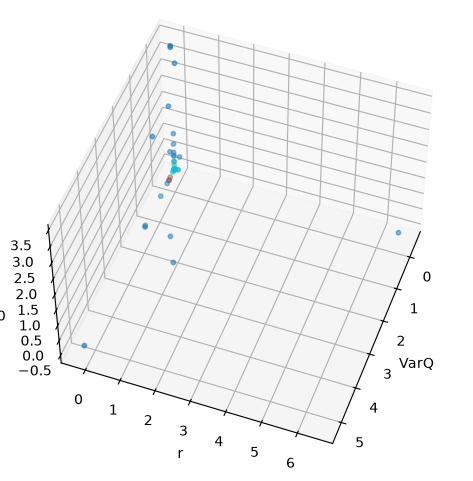

In [16]:

clusters_params_filter_LEO(csv_path)
base = Path.cwd() ## pointe vers folder parent, ici maneuver_detection

csv_path = Path(os.path.join(base, 'best_f1_clusters.csv'))

viz_on_params(csv_path)

In [17]:

import numpy as np 
def stats_on_params(csv_path):
    df=pd.read_csv(csv_path)
    fig , axes = plt.subplots(1,3, figsize=(14,4))
    
    params = ['var_Q', 'r', 'p0']
    means = []
    var = []
    for ax, col in zip(axes, params):
        means.append(np.mean(df[col]))
        var.append(np.std(df[col]))
        ax.scatter(df.index, df[col], c=df['cluster'], cmap='tab10')
        ax.set_title(col)
        ax.set_xlabel('objet')
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
    print(f"moyennes : varQ = {means[0]}, r = {means[1]}, p0= {means[2]}")
    print(f"variances : varQ = {var[0]}, r = {var[1]}, p0= {var[2]}" )
    return means, var
    

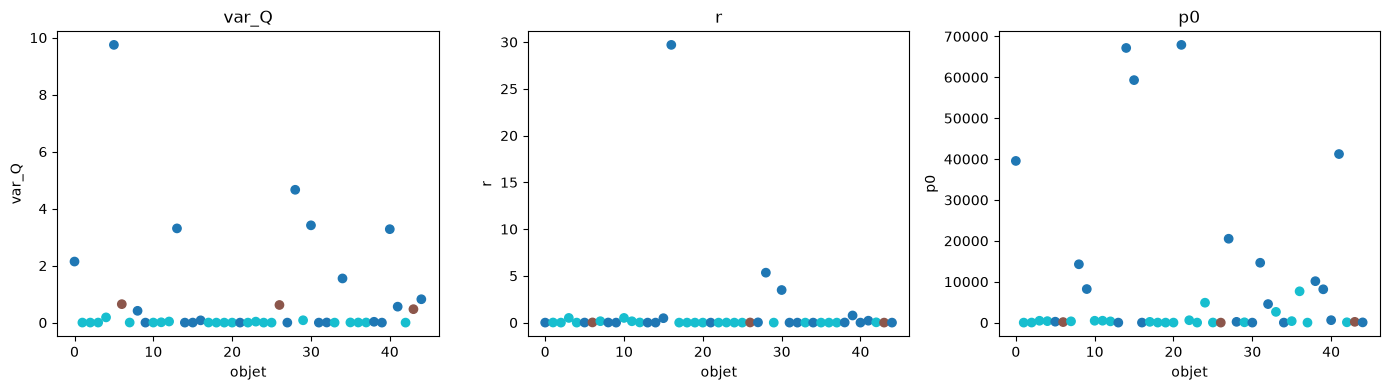

moyennes : varQ = 0.7139214377533307, r = 0.9204869173721874, p0= 8353.234868986756
variances : varQ = 1.7408692478975347, r = 4.436867231652898, p0= 17609.086222583792


([np.float64(0.7139214377533307),
  np.float64(0.9204869173721874),
  np.float64(8353.234868986756)],
 [np.float64(1.7408692478975347),
  np.float64(4.436867231652898),
  np.float64(17609.086222583792)])

In [18]:
stats_on_params(csv_path)

In [19]:
from maneuver_detection.discrete_kalman_filter import detect_kalman
import polars as pl
## on utilise la catégorisation fail, mid, good définie au début, sets de norads passés à la fonction 

def run_filter_and_plot_with_optimal_params(norads, params, csv_path, path_tle_spacetrack):
    df = (
                pl.scan_parquet(path_tle_spacetrack)
                .filter(pl.col("norad") == norad)
                .select("epoch", "sma", "inclination")
                .sort("epoch")
                .collect()
            )
    
    with open(csv_path) as f: 
        reader=csv.DictReader(f) ## chaque ligne est un dict
        header=next(reader)
        for row in reader:
            norad = row['norad']
            if norad not in norads: 
                continue 
            var_Q = row['var_Q']
            r = row['r']
            p0 = row['p0']
            detect_kalman(df, ordre = row['order'], var_Q=var_Q, r=r, p0=p0)

def run_filter_and_plot_with_avg_params(norads, csv_path):
    return 


## Run des filtres avec paramètres optimaux / moyens / de clusters

On repart des paramètres optimaux par satellite (`best_f1_clusters.csv`, produit plus haut) et on compare **trois configurations** de paramètres du filtre de Kalman :

- **optim** : les paramètres $(var_Q, r, p_0)$ optimisés satellite par satellite ;
- **avg** : les paramètres moyens sur tout le dataset labellisé (cf. `stats_on_params`) ;
- **cluster** : les paramètres moyens du cluster HDBSCAN auquel appartient le satellite (fallback sur les params moyens globaux pour les points bruit, cluster $= -1$).

Pour chaque run on produit :
1. l'évolution des paramètres orbitaux ($a$, $e$, $i$) superposée aux manoeuvres **prédites** (style `viz.time_series.plot_time_series`, comme dans les autres repos) ;
2. la NIS en pics avec le seuil $\chi^2$, les détections, et les manoeuvres vraies en surimpression.

Les figures sont sauvées dans `rapport/figures`.

NB : le `min_cluster_size` de HDBSCAN est d'abord optimisé (DBCV + fraction de bruit), puis la colonne `cluster` de `best_f1_clusters.csv` est re-générée avec la valeur retenue.

In [20]:
## Setup : paths, manoeuvres vraies, métriques -----------------------------
import re
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from maneuver_detection.discrete_kalman_filter import detect_kalman
from viz.time_series import plot_time_series
from optimisation_seuil.metrics import confusion_matrix, precision_recall_f1

base = Path.cwd()  ## pointe vers maneuver_detection

## données TLE spacetrack (adapter le path si besoin)
path_tle_spacetrack = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'SPACETRACK', 'dataframe_rivesalt_from_spacetrack.parquet'))

## labels manuels : un csv output_ephemeride_<norad>*.csv par satellite
true_man_dir = Path(os.path.join(base, '..', '..', 'data', 'parsed', 'manual_labels_LEO'))

## csv hyperparams + clusters, produit plus haut par clusters_params_filter_LEO
clusters_csv = Path(os.path.join(base, 'best_f1_clusters.csv'))

## dossier de sortie des figures du rapport
figures_dir = Path(os.path.join(base, '..', '..', 'rapport', 'figures'))
figures_dir.mkdir(parents=True, exist_ok=True)

ALPHA = 0.997  
PARAMS_PLOT = ["sma", "eccentricity", "inclination"]


def load_true_maneuvers(true_man_dir):
    """{norad: manoeuvres vraies (pd.Series de datetimes)} depuis les labels manuels."""
    true_maneuvers = {}
    for p in sorted(Path(true_man_dir).glob("*.csv")):
        m = re.search(r"output_ephemeride_(\d+)", p.name)
        if m is None:
            continue
        norad = int(m.group(1))
        dfm = pd.read_csv(p)
        true_maneuvers[norad] = pd.to_datetime(dfm['date'], errors="coerce").dropna()
    return true_maneuvers

true_maneuvers = load_true_maneuvers(true_man_dir)


def to_days(times, t0):
    """datetimes (np.datetime64 / datetime) -> float jours depuis t0."""
    arr = np.asarray(times, dtype="datetime64[ns]")
    return (arr - np.datetime64(t0, "ns")).astype("float64") / 8.64e13


def load_sat(norad):
    """DataFrame polars (epoch, sma, inclination) trié par epoch, ou None si absent."""
    df = (
        pl.scan_parquet(path_tle_spacetrack)
        .filter(pl.col("norad") == norad)
        .select("epoch", "sma", "inclination")
        .sort("epoch")
        .collect()
    )
    return None if df.is_empty() else df


def metrics_vs_labels(df, epoch, man_idx, norad):
    """F1 / precision / recall vs labels manuels (conventions de test_kalman_on_LEO)."""
    true_dt = true_maneuvers.get(norad)
    if true_dt is None or not len(true_dt):
        return None
    e = df["epoch"].to_numpy()
    true_np = true_dt.to_numpy()
    true_np = true_np[(true_np >= e[0]) & (true_np <= e[-1])]
    if not len(true_np):
        return None
    t0 = epoch[0]
    conf = confusion_matrix(to_days(true_np, t0), to_days(epoch[man_idx], t0), tol_days=TOL_DAYS)
    return {**precision_recall_f1(conf), **conf}


def f1_for_params(norad, order, var_Q, r, p0):
    """F1 vs labels manuels pour un jeu de params, sans produire de figure."""
    df = load_sat(norad)
    if df is None:
        return None
    epoch, _, nis, man_idx, _ = detect_kalman(
        df, ordre=int(order), var_Q=float(var_Q), r=float(r), p0=float(p0),
        alpha=ALPHA, plot=False, metrique='sma', tol_days=TOL_DAYS
    )
    return metrics_vs_labels(df, epoch, man_idx, norad)

In [21]:
## Catégorisation fail / mid / good / perfect (mêmes seuils que ratios()) ---

def categorize_by_f1(csv_path):
    """Répartit les norads en fail / mid / good / perfect selon la F1 optimale."""
    df = pd.read_csv(csv_path)
    cats = {
        "fail":    df[df.f1 < 0.5],
        "mid":     df[(df.f1 >= 0.5) & (df.f1 < 0.7)],
        "good":    df[(df.f1 >= 0.7) & (df.f1 < 1.0)],
        "perfect": df[df.f1 >= 1.0],
    }
    return {k: v.norad.astype(int).tolist() for k, v in cats.items()}

categories = categorize_by_f1(clusters_csv)
{k: len(v) for k, v in categories.items()}

{'fail': 9, 'mid': 7, 'good': 16, 'perfect': 13}

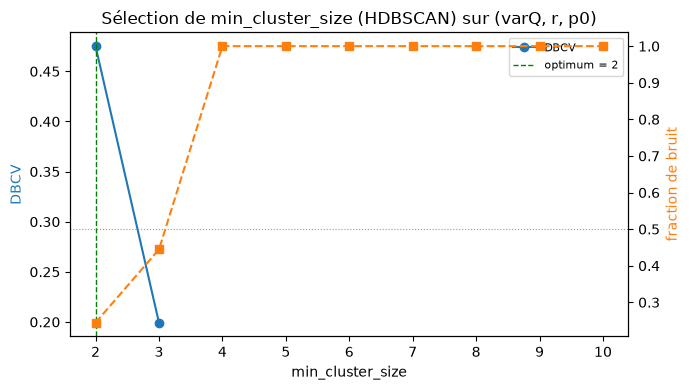

 min_cluster_size  n_clusters  noise_ratio     dbcv
                2           7     0.244444 0.475131
                3           2     0.444444 0.199282
                4           0     1.000000      NaN
                5           0     1.000000      NaN
                6           0     1.000000      NaN
                7           0     1.000000      NaN
                8           0     1.000000      NaN
                9           0     1.000000      NaN
               10           0     1.000000      NaN
=> min_cluster_size optimal : 2
cluster
-1    11
 0     4
 1     3
 2     4
 3     3
 4     2
 5     2
 6    16
Name: count, dtype: int64


In [22]:
## Borne optimale HDBSCAN : scan de min_cluster_size ------------------------
## critères : DBCV (validity index, à maximiser) et fraction de bruit (à limiter)
from sklearn.preprocessing import StandardScaler
import hdbscan
from hdbscan.validity import validity_index


def optimise_hdbscan(csv_path, sizes=range(2, 11), max_noise=0.5):
    """Scanne min_cluster_size et retient la valeur maximisant le DBCV
    parmi celles laissant au plus `max_noise` de points en bruit."""
    df = pd.read_csv(csv_path)
    X = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']]).astype(np.float64)
    rows = []
    for s in sizes:
        labels = hdbscan.HDBSCAN(min_cluster_size=int(s)).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = float(np.mean(labels == -1))
        try:
            dbcv = float(validity_index(X, labels)) if n_clusters >= 2 else np.nan
        except Exception:
            dbcv = np.nan
        rows.append({"min_cluster_size": int(s), "n_clusters": n_clusters,
                     "noise_ratio": noise, "dbcv": dbcv})
    res = pd.DataFrame(rows)

    ok = res[(res.noise_ratio <= max_noise) & res.dbcv.notna()]
    pool = ok if len(ok) else res[res.dbcv.notna()]
    best = int(pool.sort_values("dbcv", ascending=False).iloc[0].min_cluster_size)

    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(res.min_cluster_size, res.dbcv, "o-", color="tab:blue", label="DBCV")
    ax1.set_xlabel("min_cluster_size")
    ax1.set_ylabel("DBCV", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(res.min_cluster_size, res.noise_ratio, "s--", color="tab:orange")
    ax2.set_ylabel("fraction de bruit", color="tab:orange")
    ax2.axhline(max_noise, color="tab:orange", ls=":", lw=0.8)
    ax1.axvline(best, color="green", ls="--", lw=1.0, label=f"optimum = {best}")
    ax1.set_title("Sélection de min_cluster_size (HDBSCAN) sur (varQ, r, p0)")
    ax1.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(figures_dir / "kalman_hdbscan_selection.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(res.to_string(index=False))
    print(f"=> min_cluster_size optimal : {best}")
    return best, res


def recluster_with_best(csv_path, min_cluster_size):
    """Re-clusterise avec la borne optimale et met à jour la colonne cluster."""
    df = pd.read_csv(csv_path)
    X = StandardScaler().fit_transform(df[['var_Q', 'r', 'p0']]).astype(np.float64)
    df['cluster'] = hdbscan.HDBSCAN(min_cluster_size=int(min_cluster_size)).fit_predict(X)
    df.to_csv(csv_path, index=False)
    print(df.cluster.value_counts().sort_index())


best_mcs, hdbscan_scan = optimise_hdbscan(clusters_csv)
recluster_with_best(clusters_csv, best_mcs)

In [23]:
## Run du filtre + figures (params orbitaux + manoeuvres prédites, NIS en pics)

def run_filter_and_figures(norad, order, var_Q, r, p0, tag, save=True, name=None):
    """Applique le filtre Kalman à `norad` avec les params donnés puis trace :
      1. l'évolution des paramètres orbitaux superposée aux manoeuvres prédites
      2. la NIS en pics avec seuil chi2, détections et manoeuvres vraies
    Retourne les métriques (F1, precision, recall) vs labels manuels.
    Figures écrites dans rapport/figures sous {name}_params.png / {name}_nis.png
    (par défaut name = kalman_{tag}_{norad}).
    """
    norad = int(norad)
    name = name or f"kalman_{tag}_{norad}"
    df = load_sat(norad)
    if df is None:
        print(f"norad {norad} absent des données spacetrack")
        return None

    epoch, sma_dot, nis, man_idx, threshold = detect_kalman(
        df, ordre=int(order), var_Q=float(var_Q), r=float(r), p0=float(p0),
        alpha=ALPHA, plot=False, metrique='sma', tol_days=TOL_DAYS
    )
    pred_dates = list(pd.to_datetime(epoch[man_idx]))

    metrics = metrics_vs_labels(df, epoch, man_idx, norad)
    f1_txt = f" — F1={metrics['f1']:.2f}" if metrics else ""

    ## 1. évolution des paramètres orbitaux + manoeuvres prédites
    fig1 = plot_time_series(path_tle_spacetrack, norad, PARAMS_PLOT,
                            ncols=3, maneuvers=pred_dates)
    fig1.suptitle(f"NORAD {norad} — paramètres orbitaux + manoeuvres prédites ({tag}){f1_txt}",
                  fontsize=11)
    if save:
        fig1.savefig(figures_dir / f"{name}_params.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig1)

    ## 2. NIS en pics + seuil chi2 + détections + manoeuvres vraies
    fig2, ax = plt.subplots(figsize=(12, 4))
    ax.plot(epoch, nis, lw=0.8, color="tab:blue", label="NIS")
    ax.axhline(threshold, color="grey", ls="--", lw=0.8,
               label=rf"seuil $\chi^2_1$($\alpha$={ALPHA}) = {threshold:.2f}")
    if len(man_idx):
        ax.scatter(epoch[man_idx], nis[man_idx], color="red", marker="x",
                   zorder=5, label=f"manoeuvres prédites ({len(man_idx)})")
    true_dt = true_maneuvers.get(norad)
    if true_dt is not None and len(true_dt):
        for j, m in enumerate(true_dt):
            ax.axvline(m, color="green", ls=":", lw=0.7, alpha=0.6,
                       label="manoeuvres vraies" if j == 0 else None)
    ax.set_ylabel(r"NIS $= y^2/S$")
    ax.set_xlabel("epoch")
    ax.set_title(f"NORAD {norad} — NIS Kalman ({tag}){f1_txt}")
    e_full = df['epoch'].to_numpy()
    ax.set_xlim(e_full[0], e_full[-1])
    ax.margins(x=0)
    ax.legend(loc="best", fontsize=8)
    fig2.tight_layout()
    if save:
        fig2.savefig(figures_dir / f"{name}_nis.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig2)

    return metrics

In [24]:
## Les trois runners : params optimaux / moyens / de clusters ---------------

def run_filters_with_optim_params(norads, csv_path, save=True, tag="optim", names=None):
    """Run du filtre pour chaque norad avec SES paramètres optimaux (csv des hyperparams)."""
    df = pd.read_csv(csv_path)
    results = {}
    for norad in norads:
        row = df[df.norad == int(norad)]
        if row.empty:
            print(f"norad {norad} absent de {csv_path}")
            continue
        row = row.iloc[0]
        results[int(norad)] = run_filter_and_figures(
            norad, row['order'], row['var_Q'], row['r'], row['p0'],
            tag=tag, save=save, name=(names or {}).get(int(norad)))
    return results


def run_filters_with_avg_params(norads, csv_path, save=True, tag="avg", names=None):
    """Run du filtre pour chaque norad avec les paramètres MOYENS sur tout le dataset."""
    df = pd.read_csv(csv_path)
    var_Q, r, p0 = df['var_Q'].mean(), df['r'].mean(), df['p0'].mean()
    order = int(df['order'].mode().iloc[0])   ## ordre majoritaire
    print(f"params moyens : var_Q={var_Q:.4g}, r={r:.4g}, p0={p0:.4g}, ordre={order}")
    results = {}
    for norad in norads:
        results[int(norad)] = run_filter_and_figures(
            norad, order, var_Q, r, p0,
            tag=tag, save=save, name=(names or {}).get(int(norad)))
    return results


def _cluster_param_tables(df):
    """(moyennes globales, moyennes par cluster, ordre global, ordre par cluster)."""
    global_means = (df['var_Q'].mean(), df['r'].mean(), df['p0'].mean())
    global_order = int(df['order'].mode().iloc[0])
    valid = df[df.cluster != -1]
    cluster_means = valid.groupby('cluster')[['var_Q', 'r', 'p0']].mean()
    cluster_orders = valid.groupby('cluster')['order'].agg(lambda s: int(s.mode().iloc[0]))
    return global_means, cluster_means, global_order, cluster_orders


def run_filters_with_cluster_params(norads, csv_path, save=True, tag="cluster", names=None):
    """Run du filtre avec les paramètres moyens du CLUSTER HDBSCAN de chaque satellite.
    Les points bruit (cluster = -1) retombent sur les params moyens globaux."""
    df = pd.read_csv(csv_path)
    global_means, cluster_means, global_order, cluster_orders = _cluster_param_tables(df)
    results = {}
    for norad in norads:
        row = df[df.norad == int(norad)]
        if row.empty:
            print(f"norad {norad} absent de {csv_path}")
            continue
        c = int(row.iloc[0]['cluster'])
        if c == -1:
            (var_Q, r, p0), order = global_means, global_order
        else:
            var_Q, r, p0 = cluster_means.loc[c].tolist()
            order = int(cluster_orders.loc[c])
        results[int(norad)] = run_filter_and_figures(
            norad, order, var_Q, r, p0,
            tag=tag, save=save, name=(names or {}).get(int(norad)))
    return results

exemples choisis : {'fail': [64467, 64575], 'mid': [28885, 62904], 'good': [64784, 65317, 63920, 39375, 49330], 'perfect': [64723, 65852]}
1


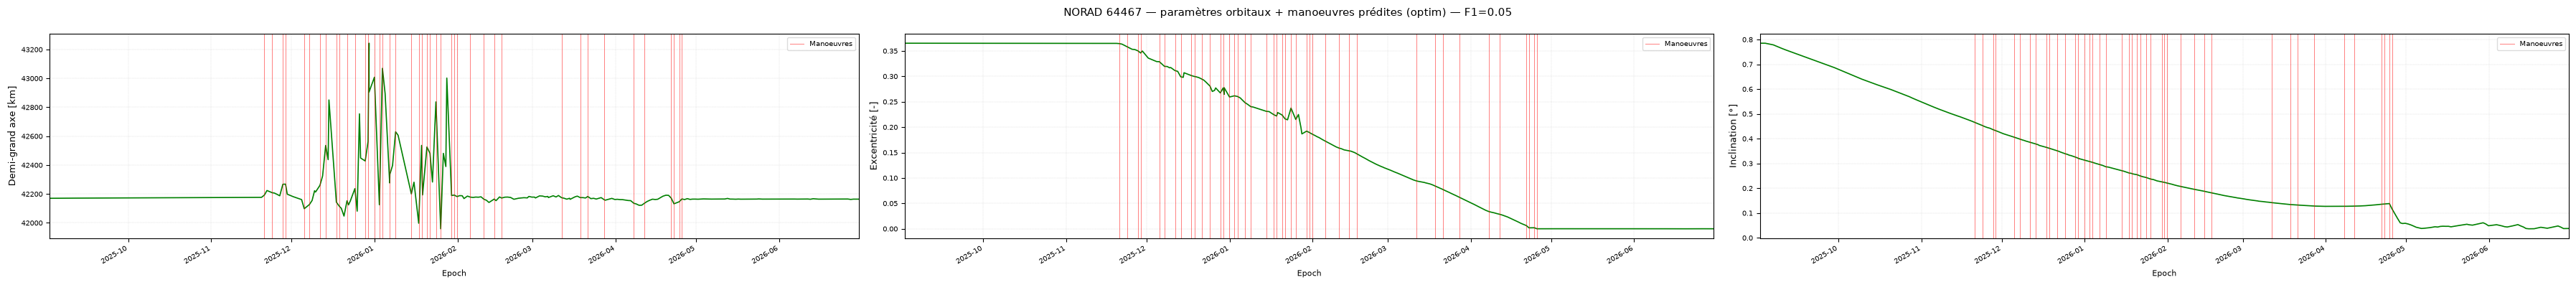

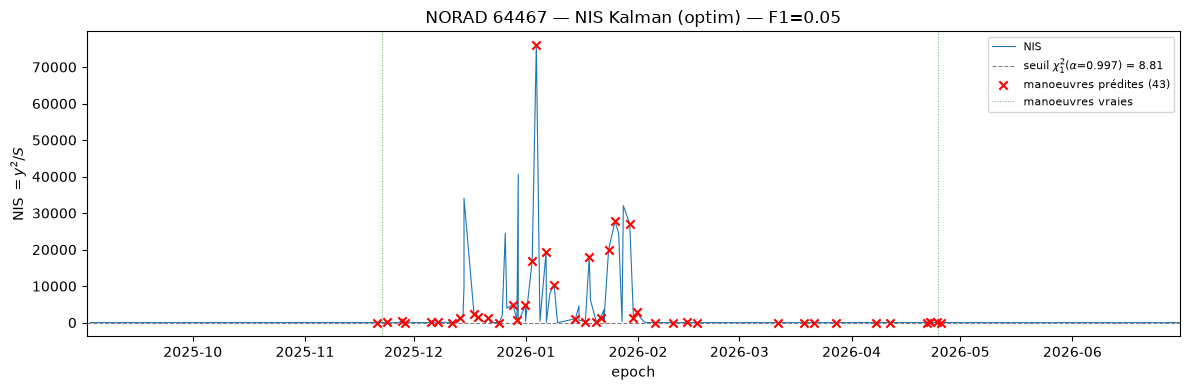

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


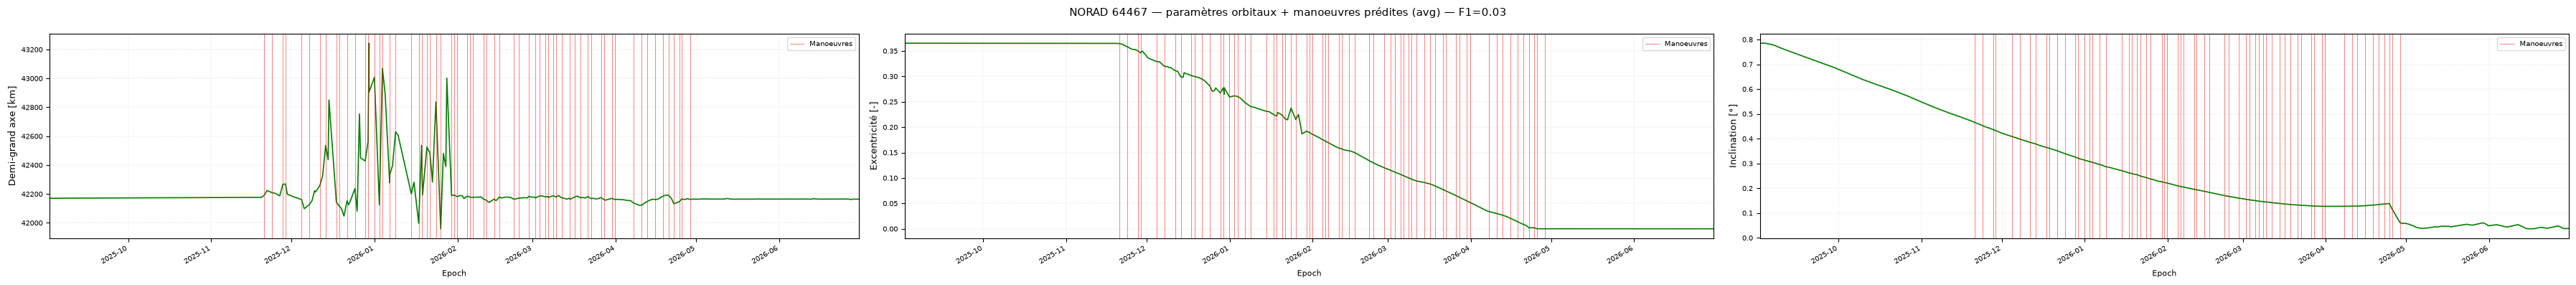

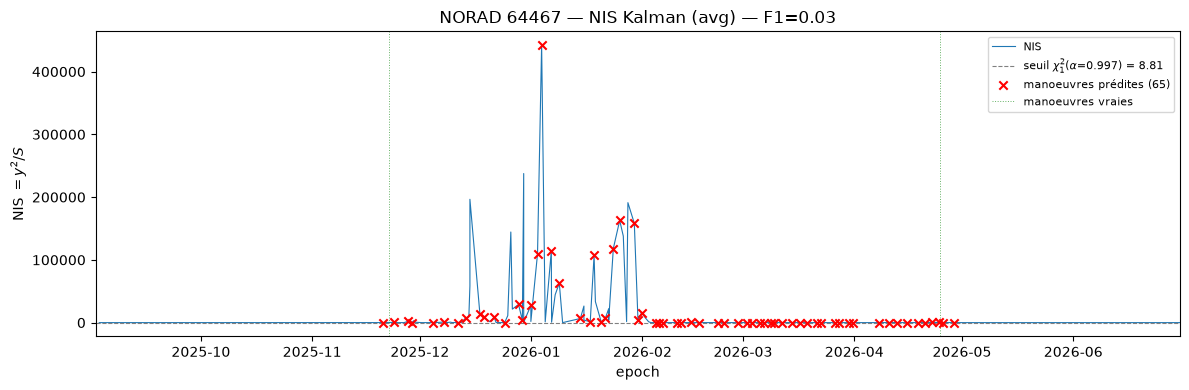

1


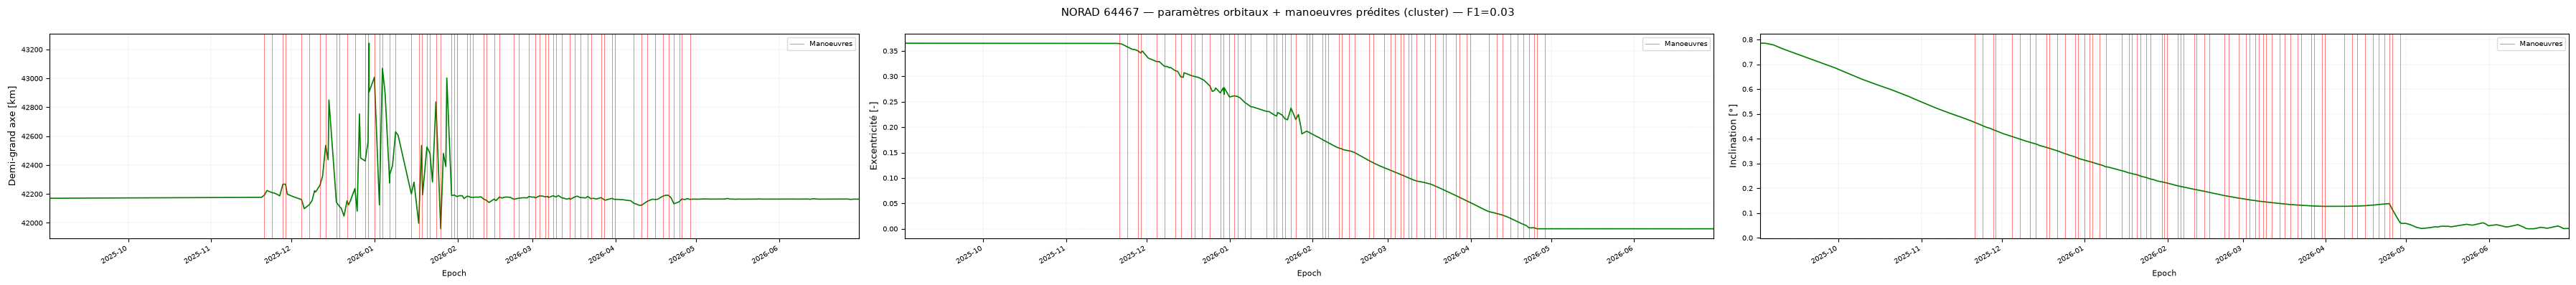

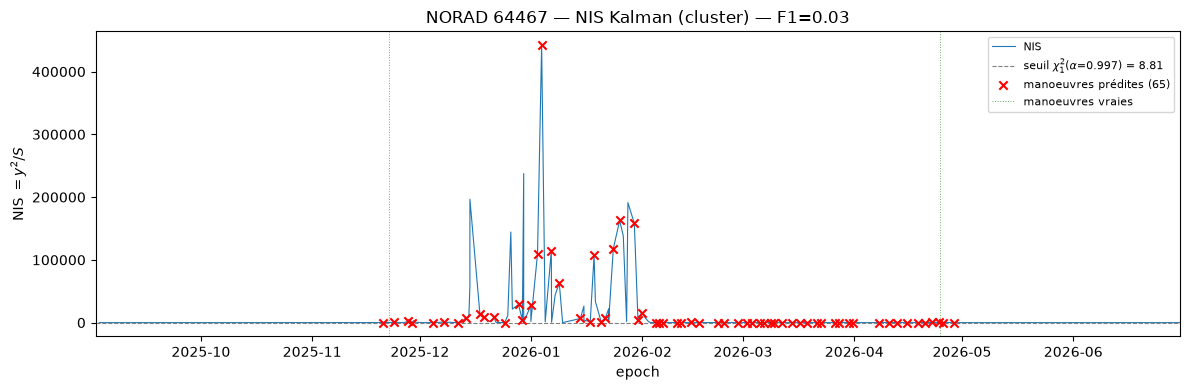

1


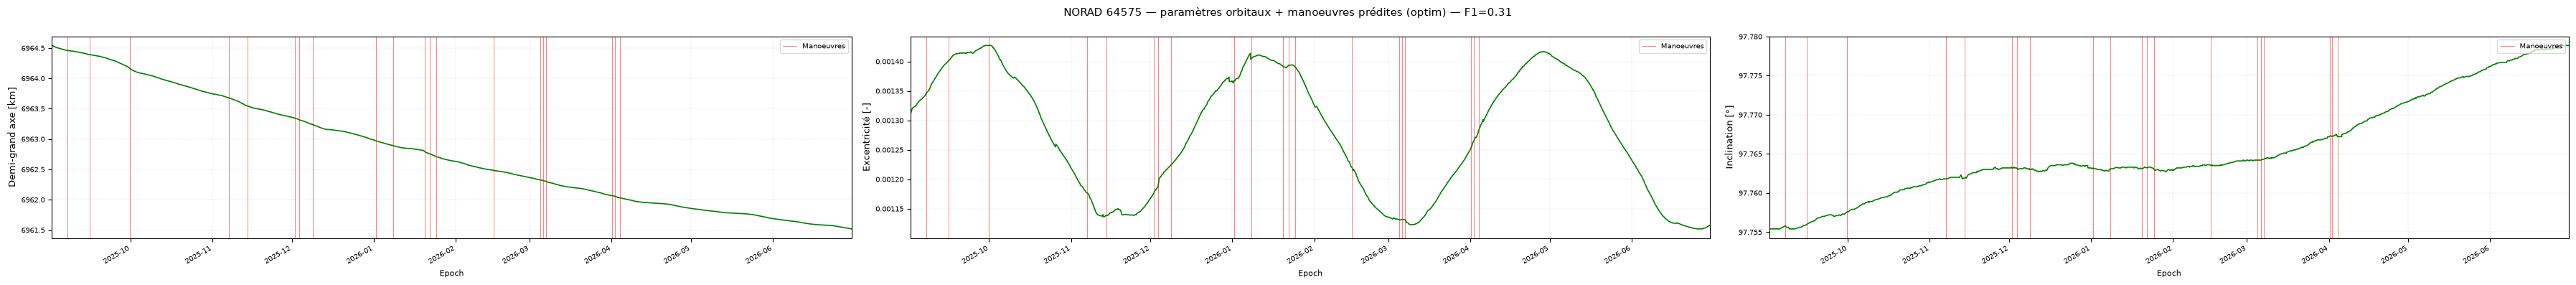

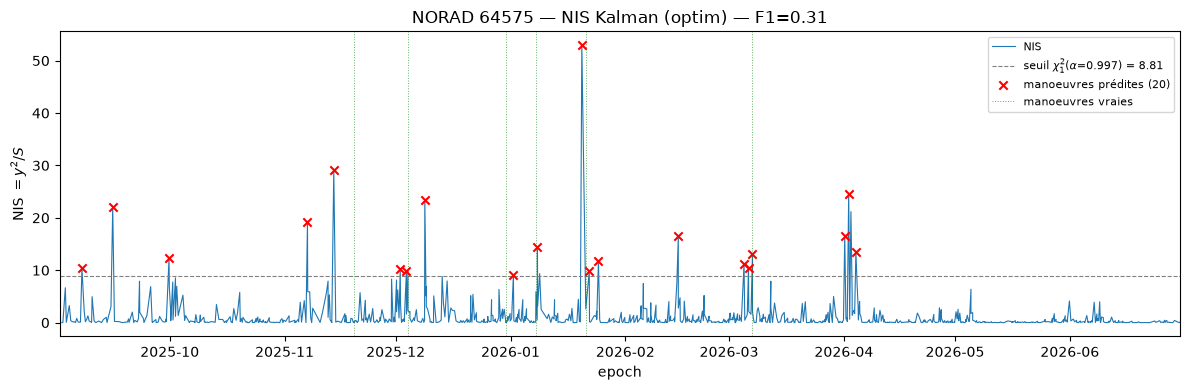

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


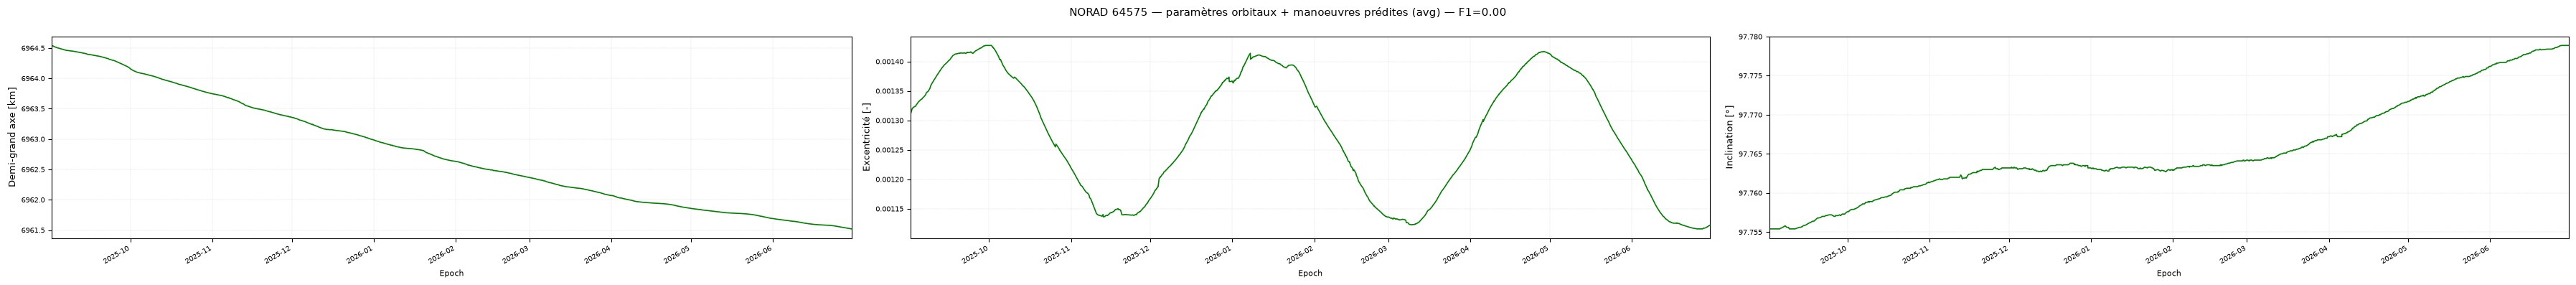

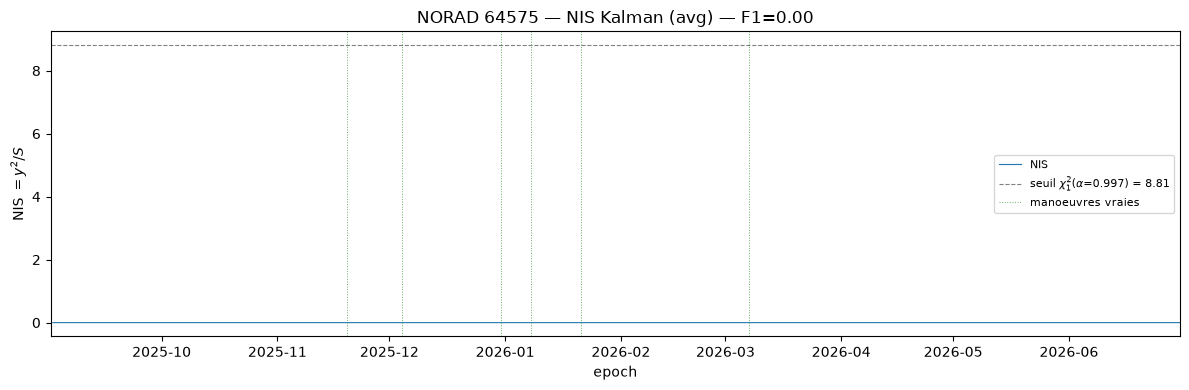

1


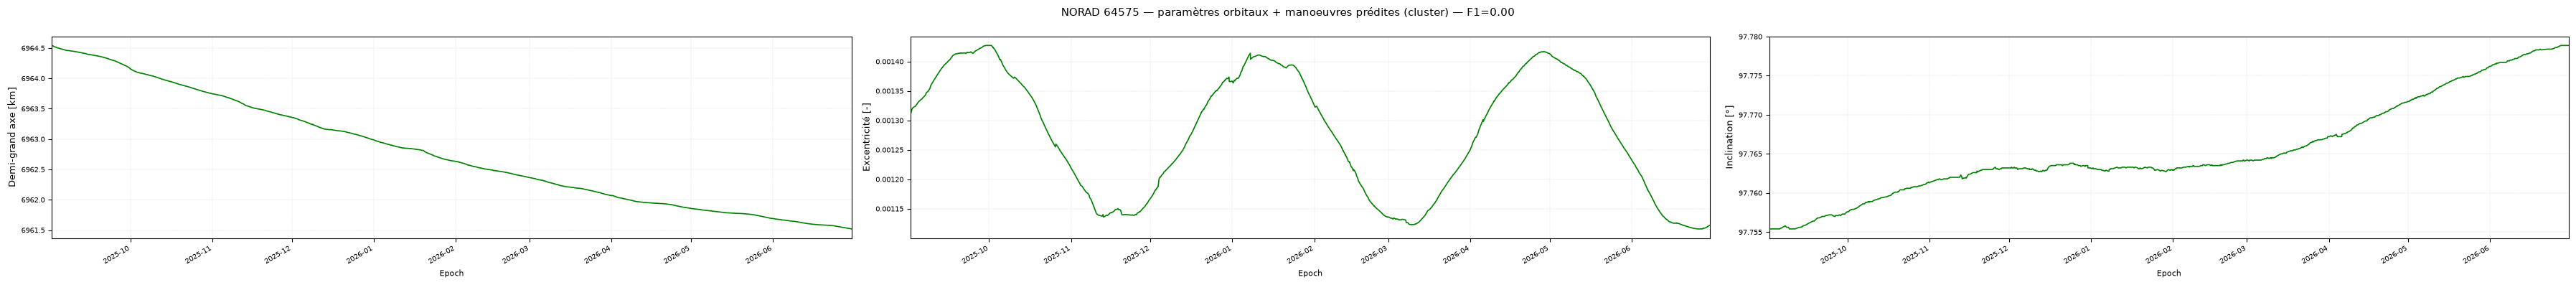

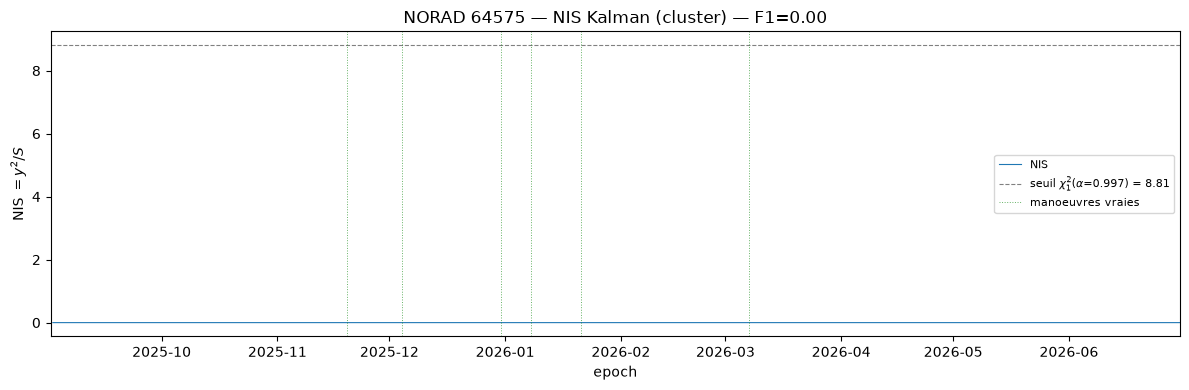

1


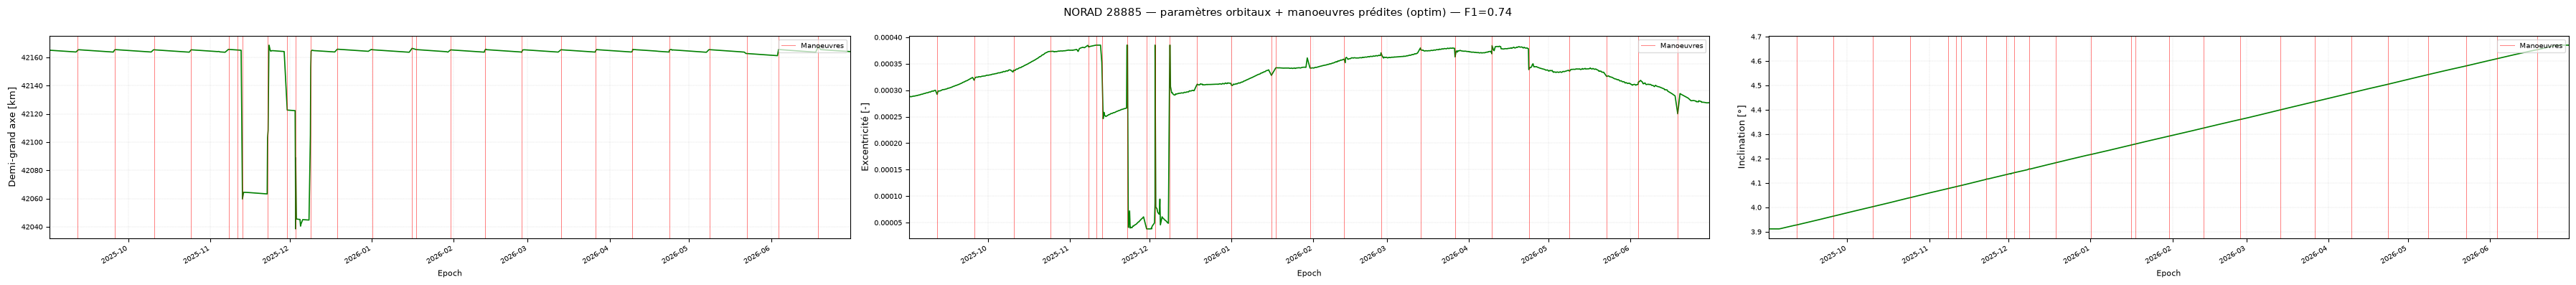

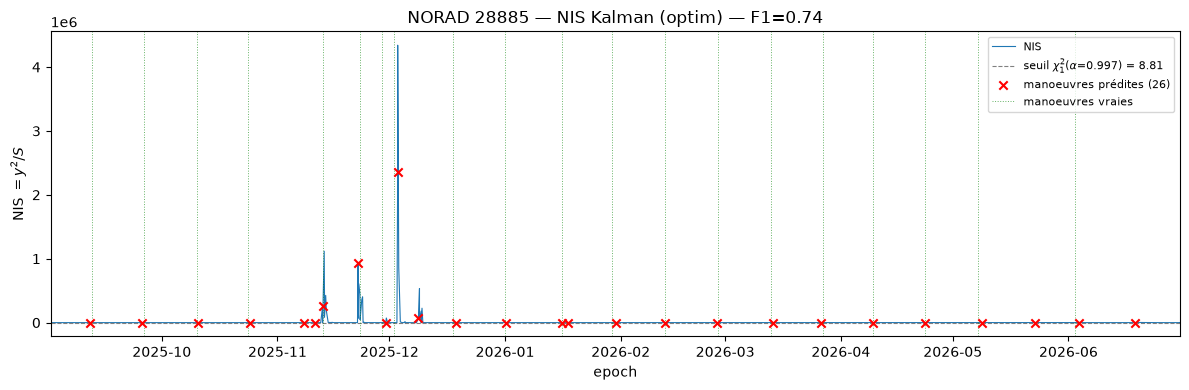

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


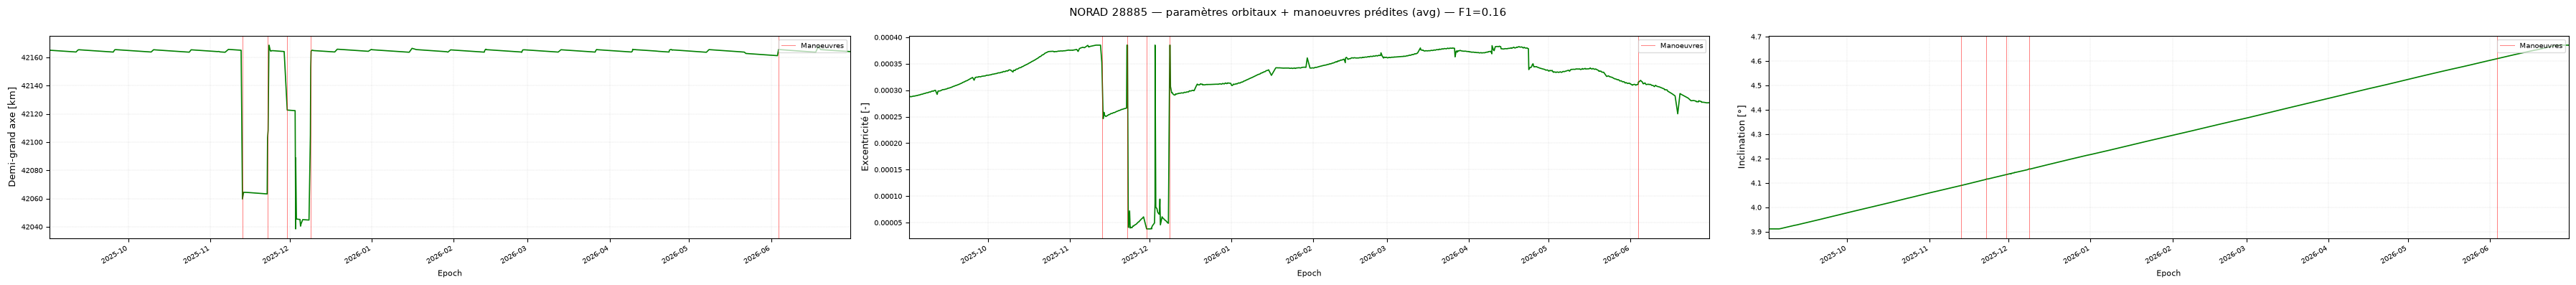

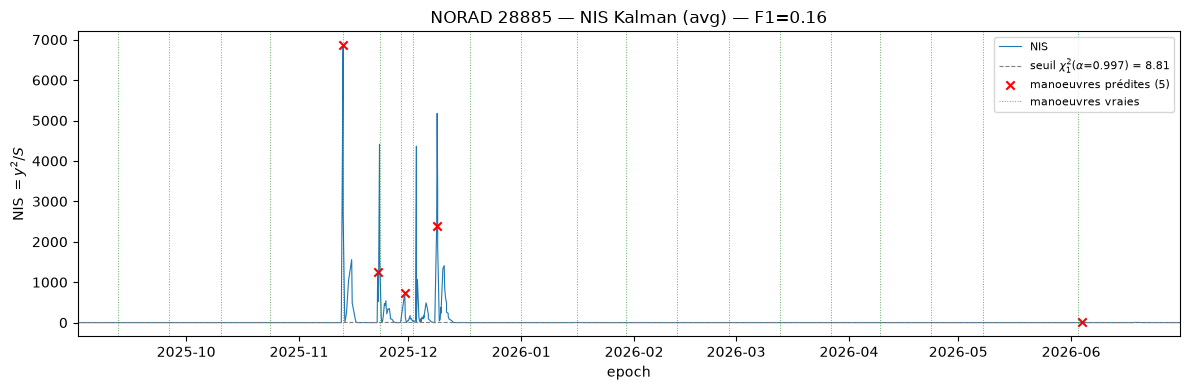

1


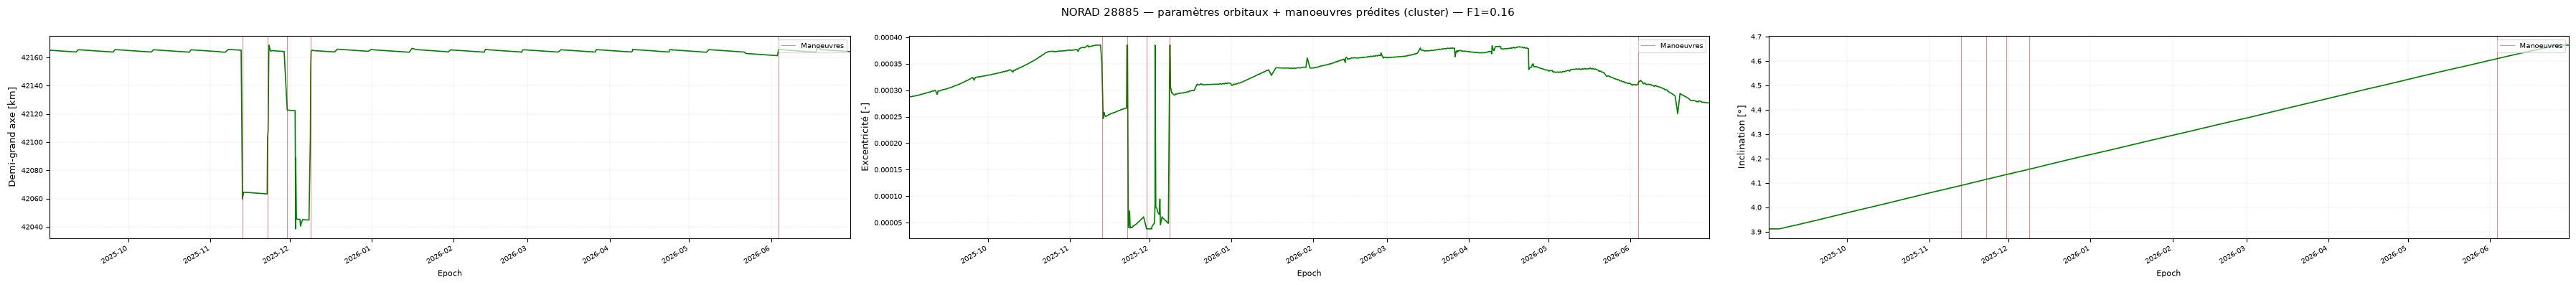

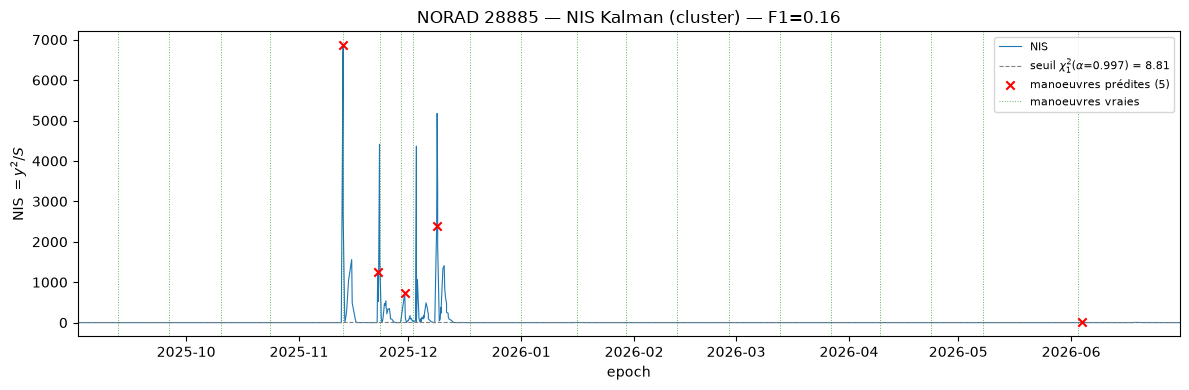

1


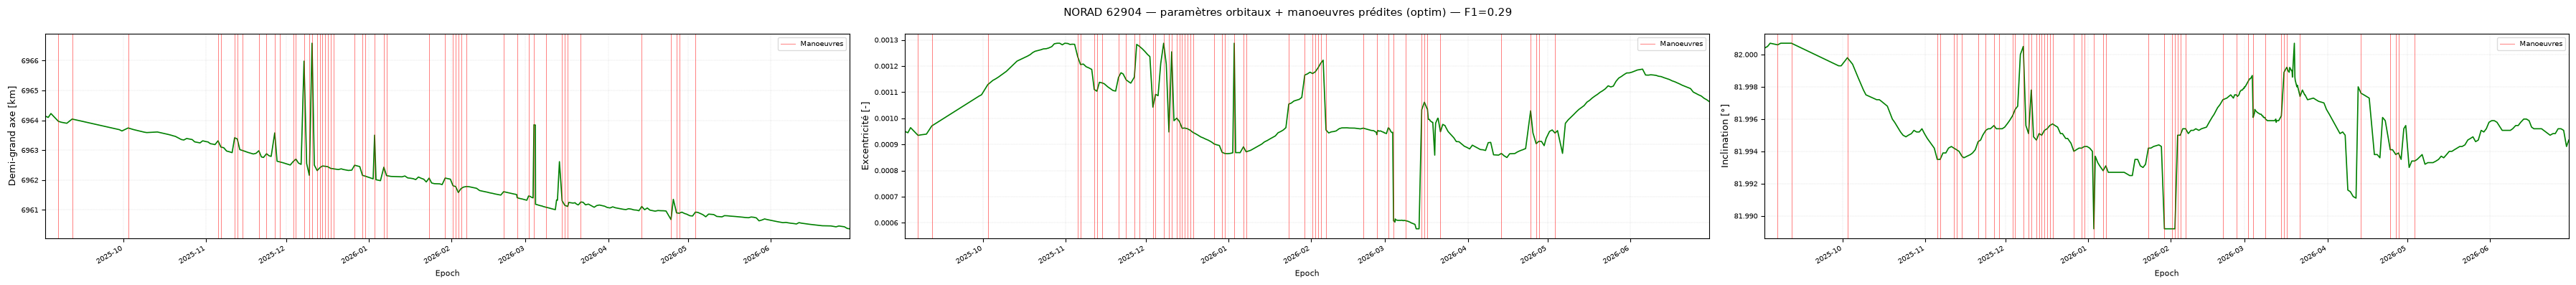

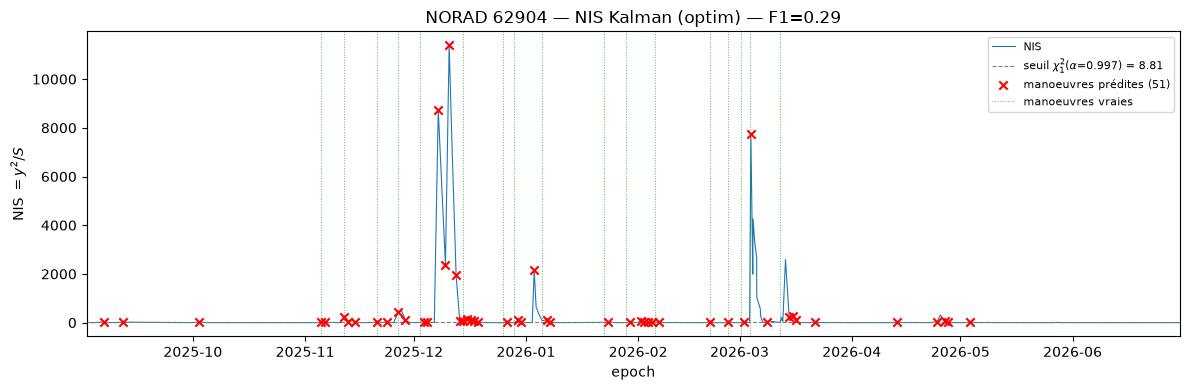

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


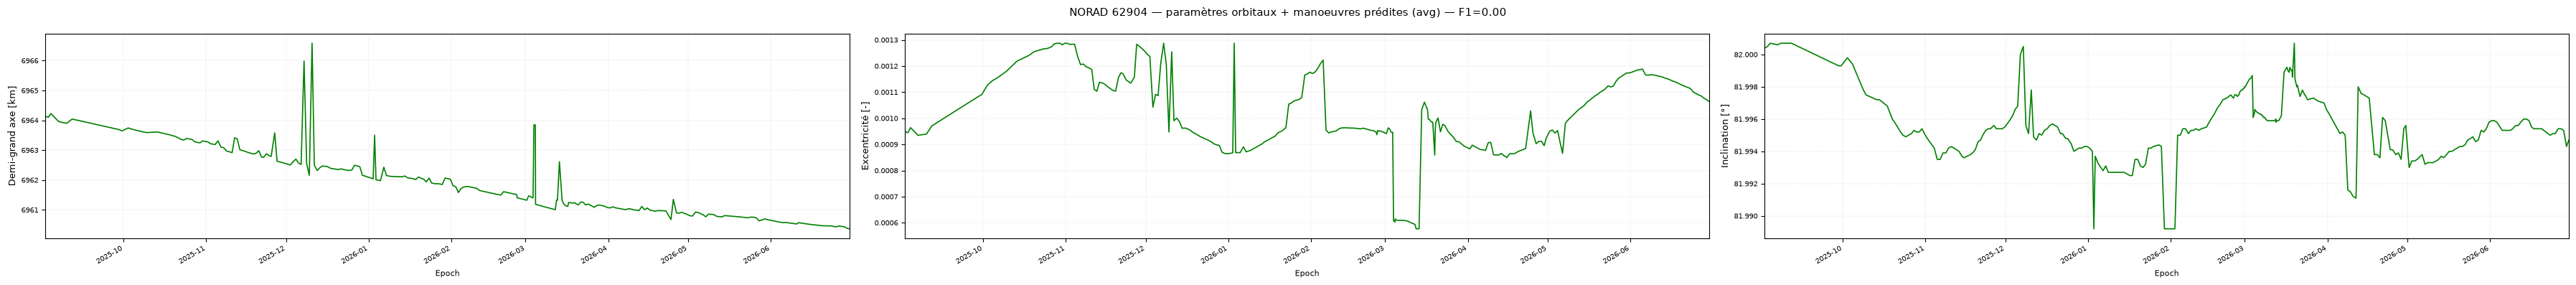

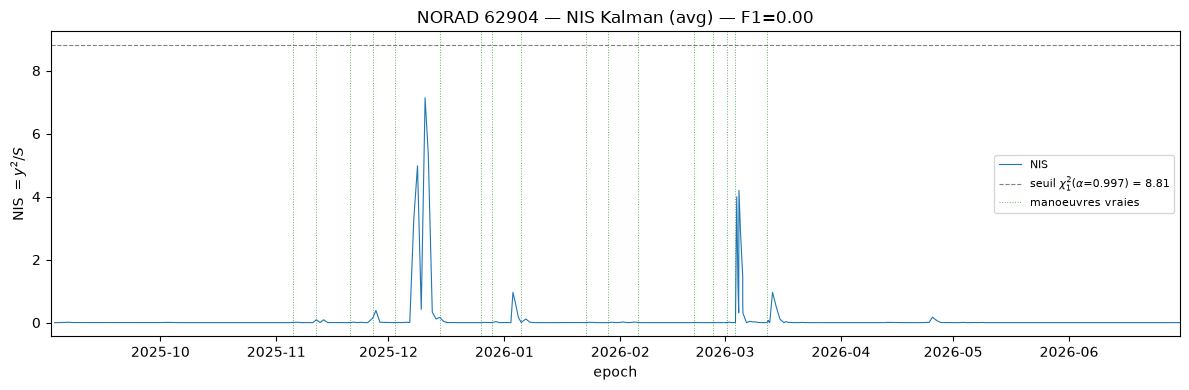

1


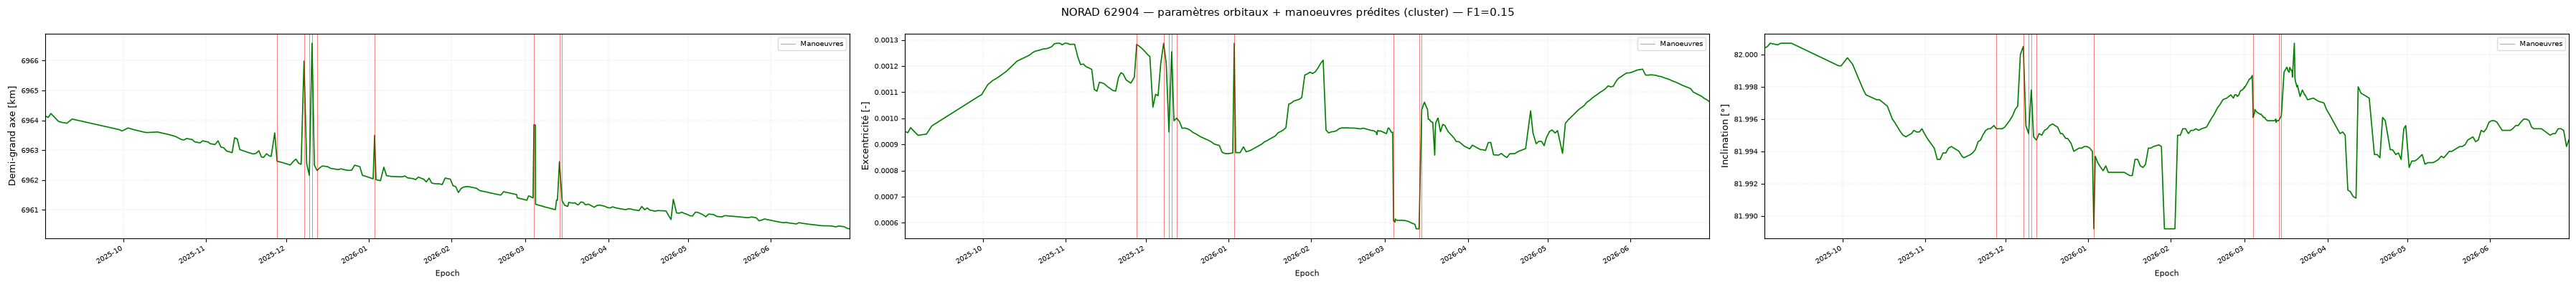

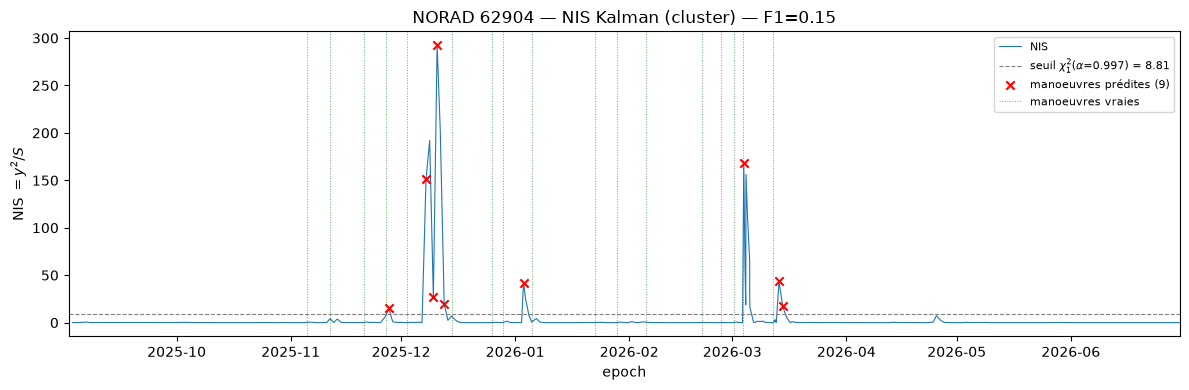

1


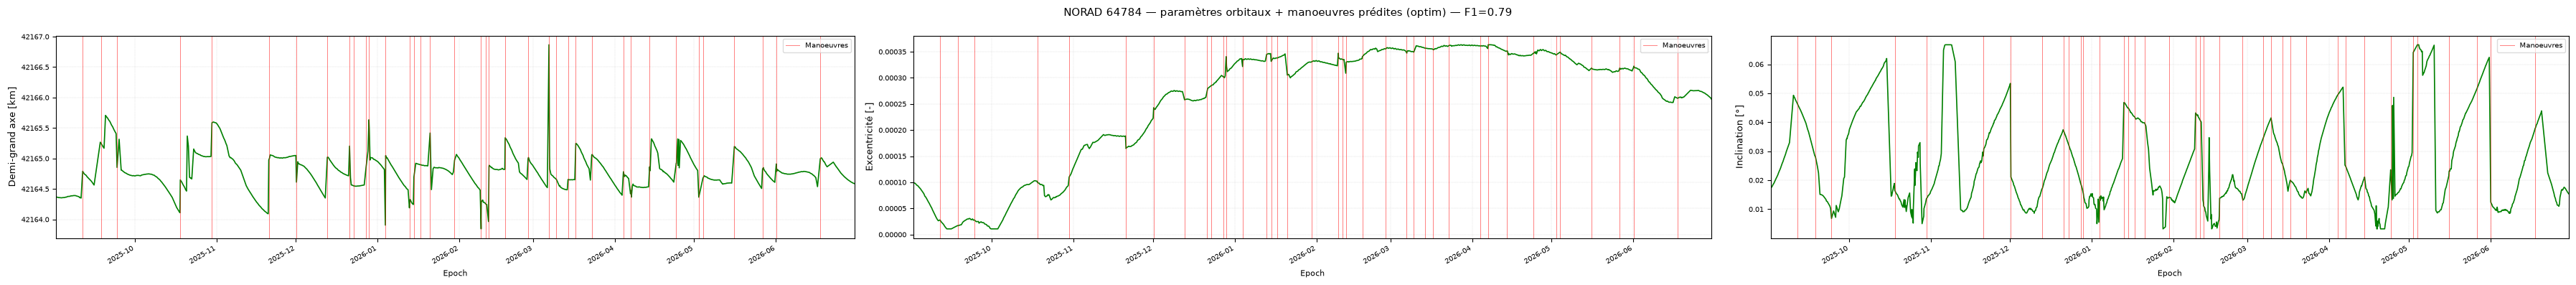

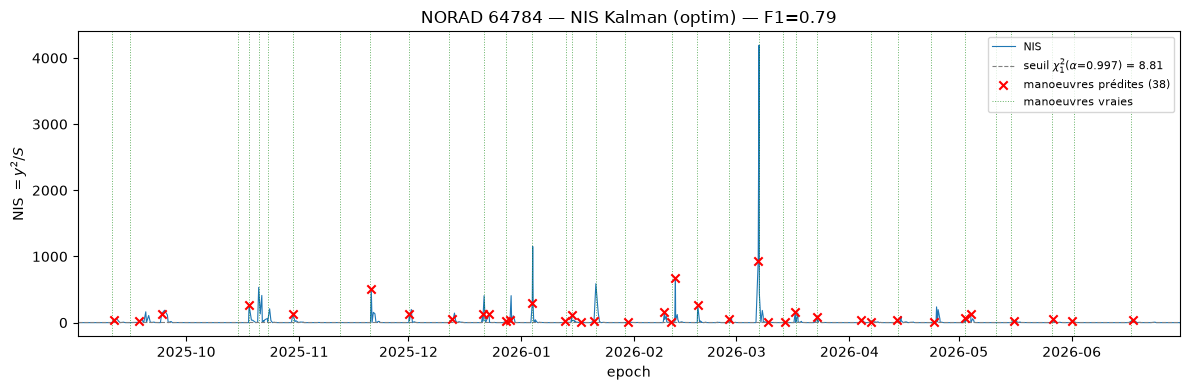

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


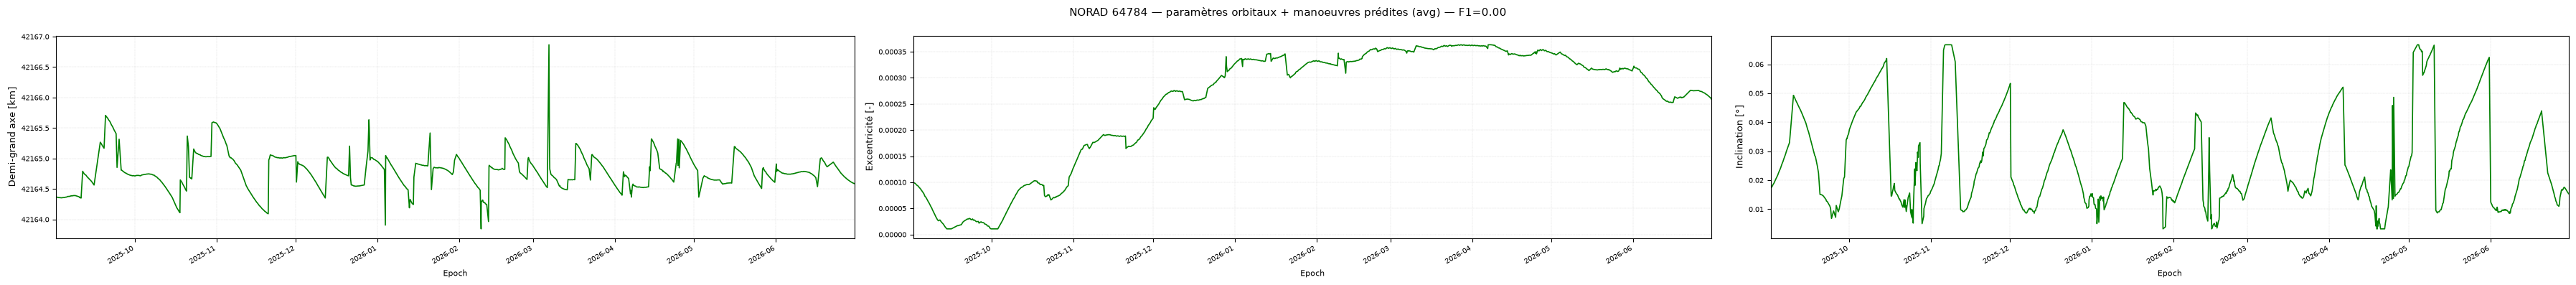

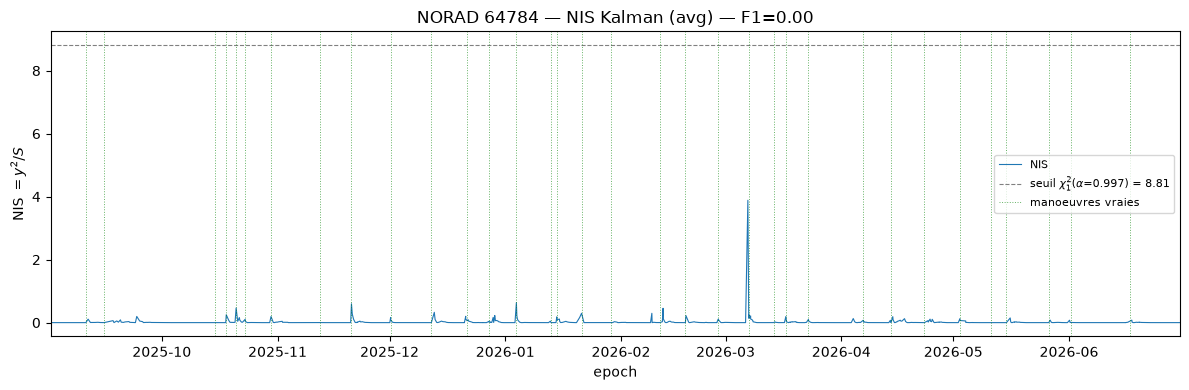

1


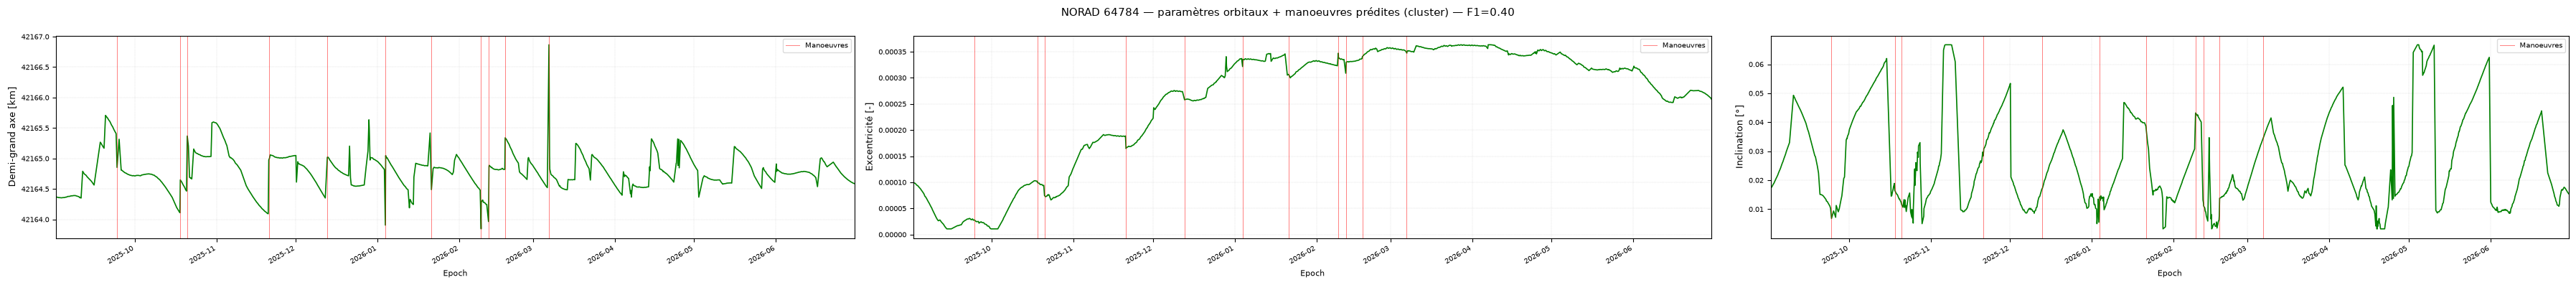

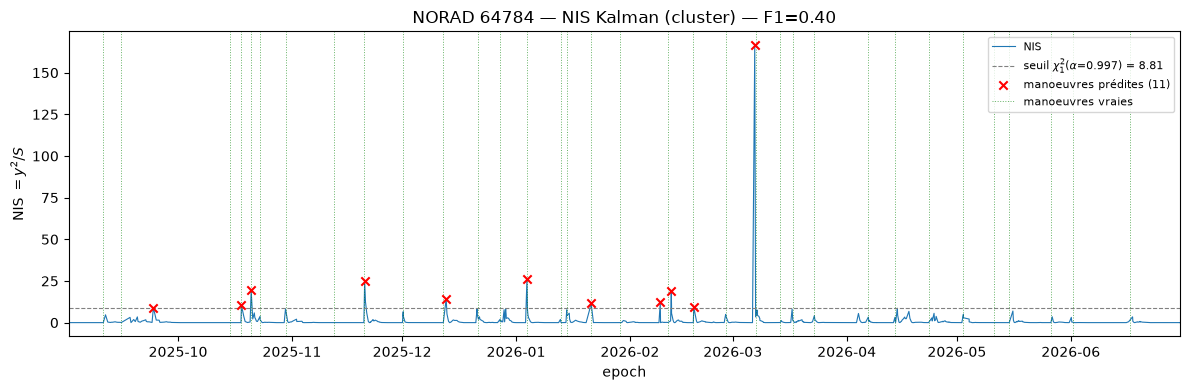

1


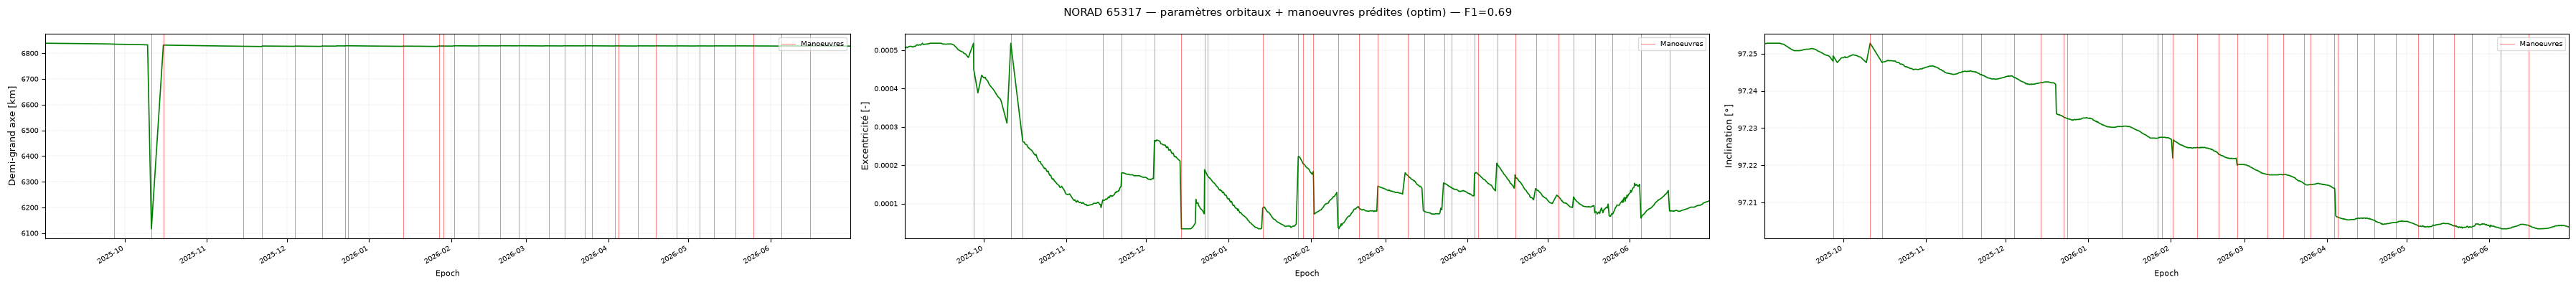

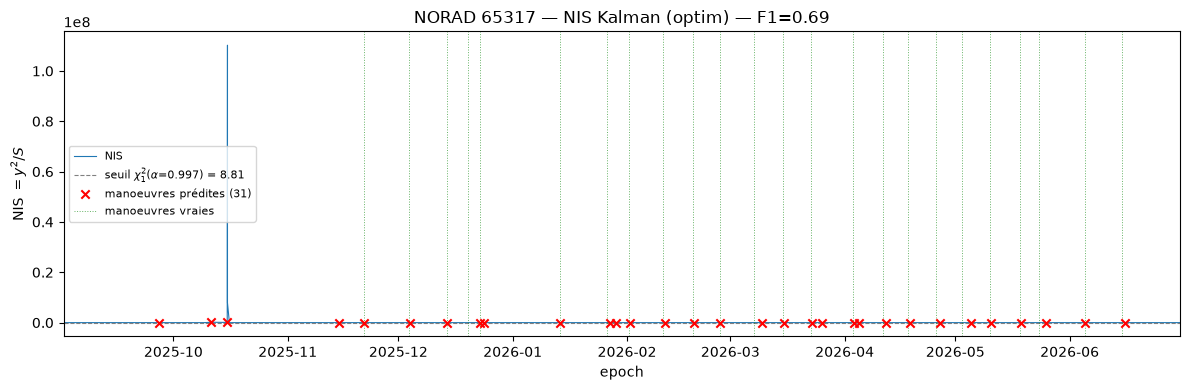

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


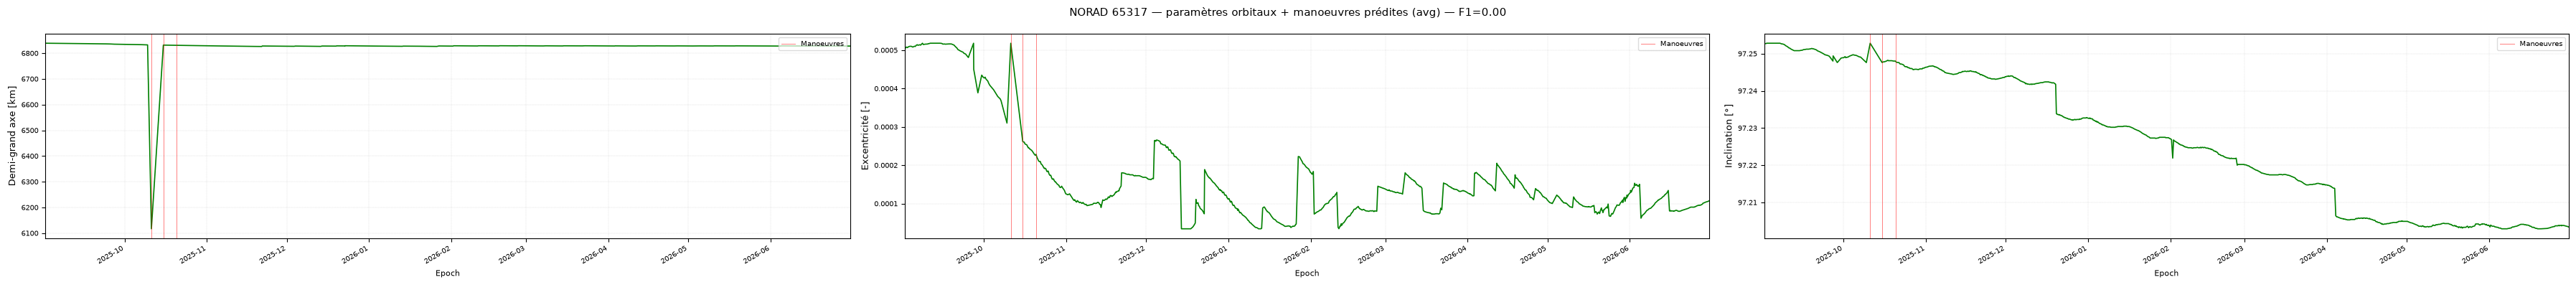

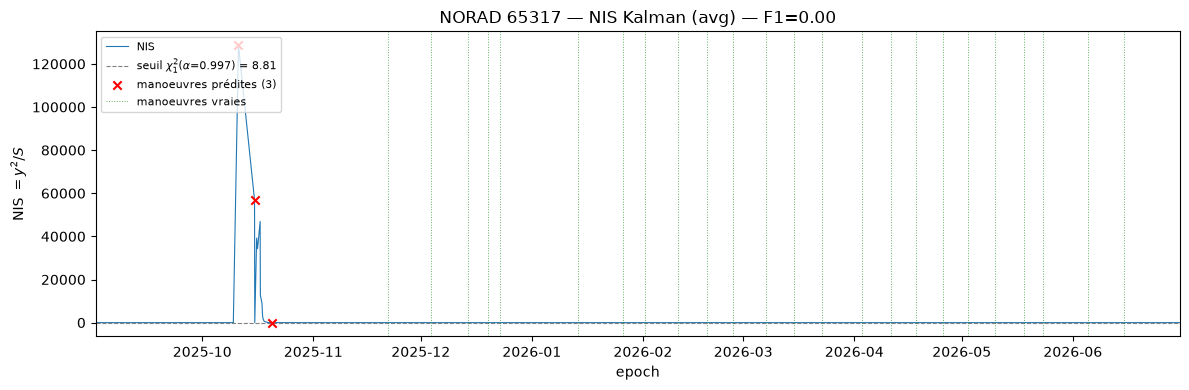

1


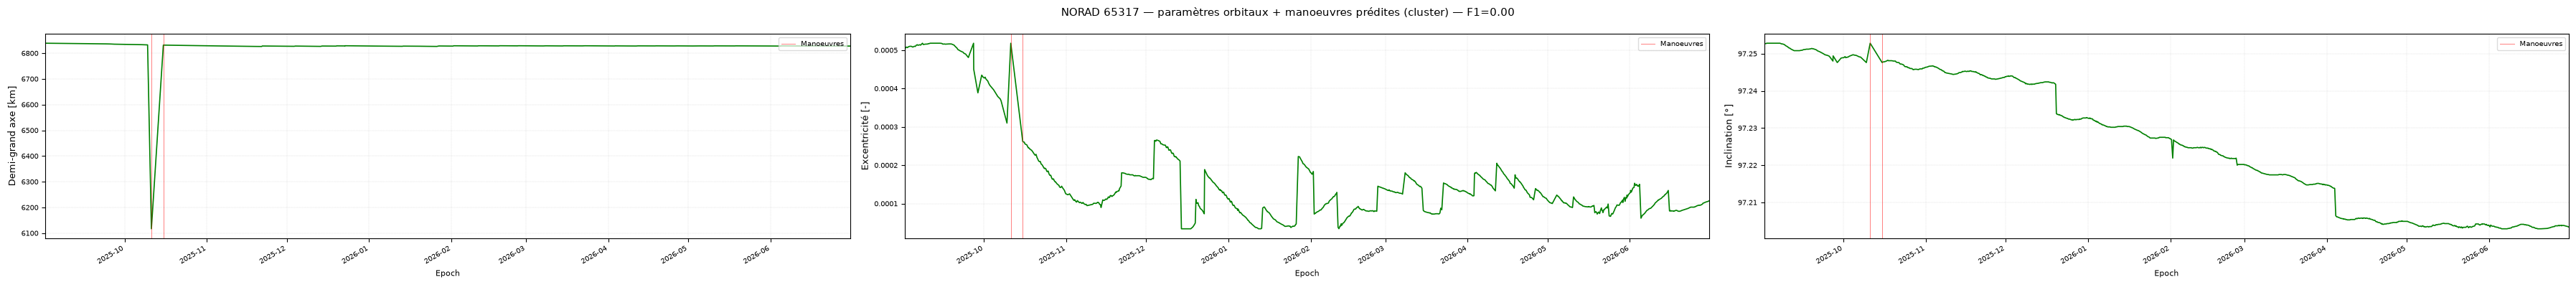

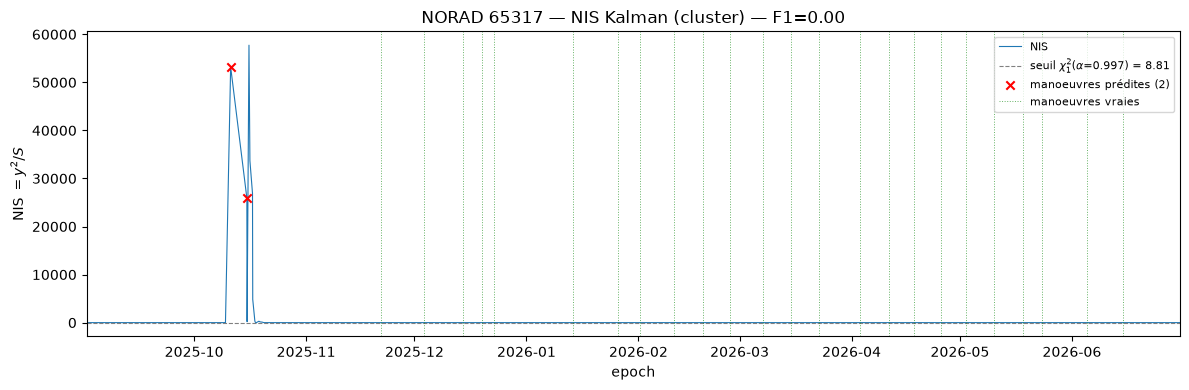

1


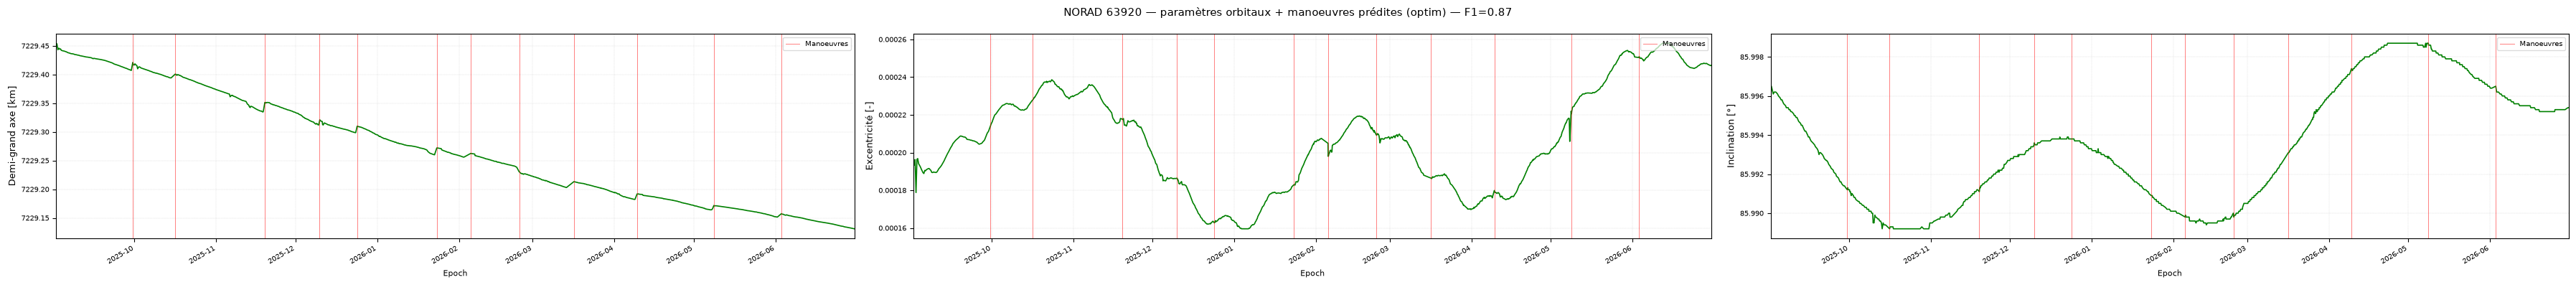

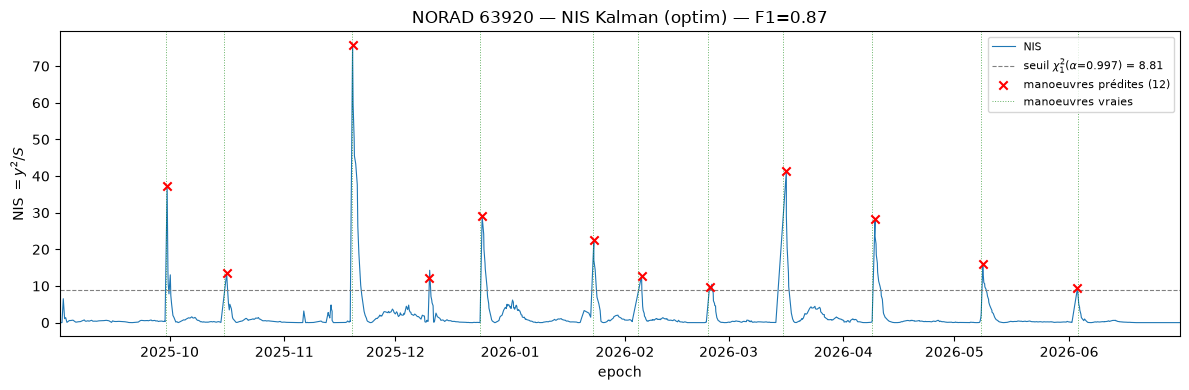

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


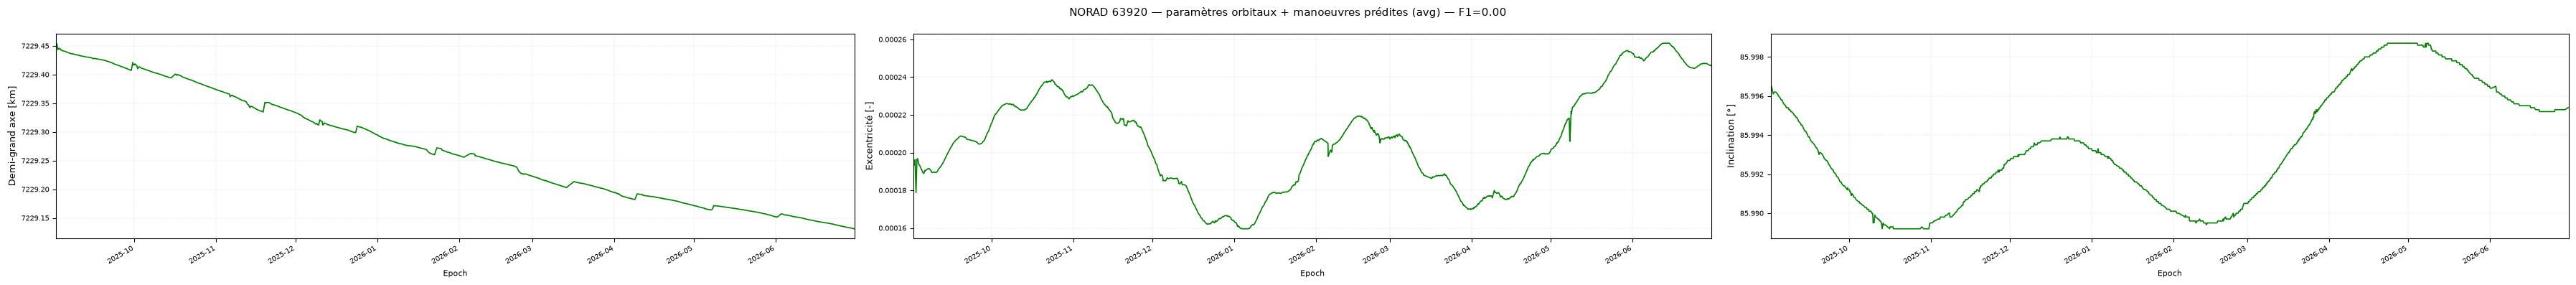

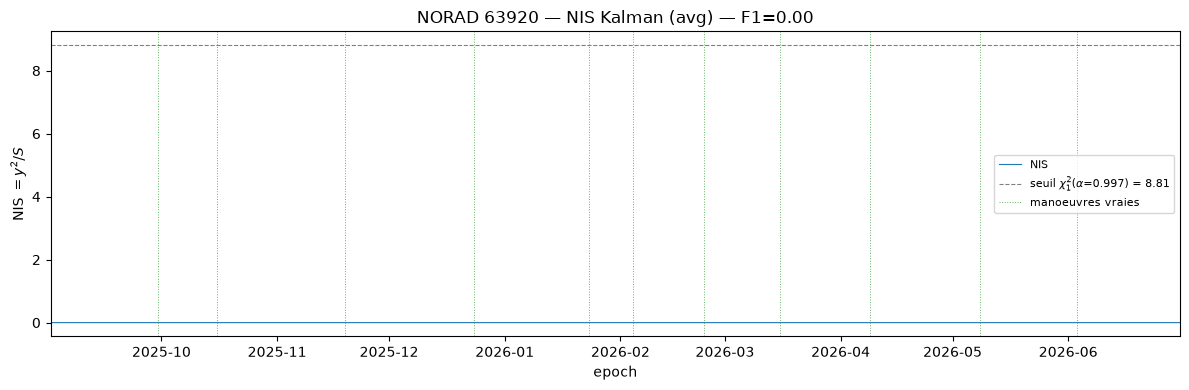

1


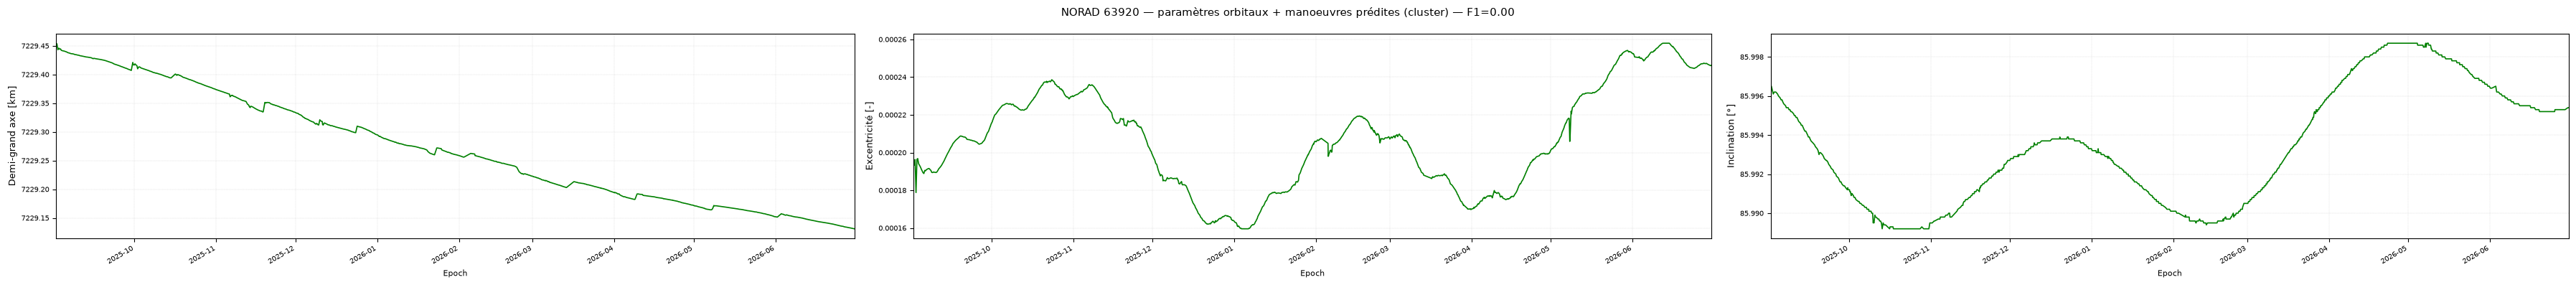

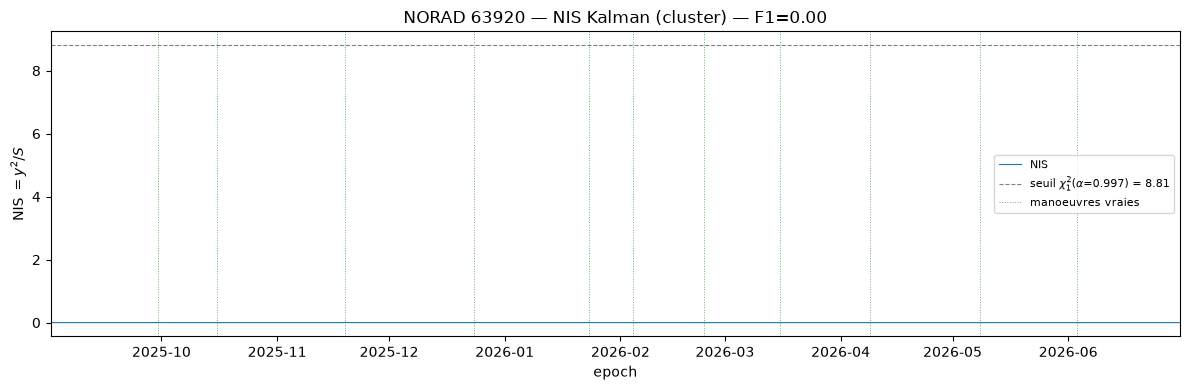

1


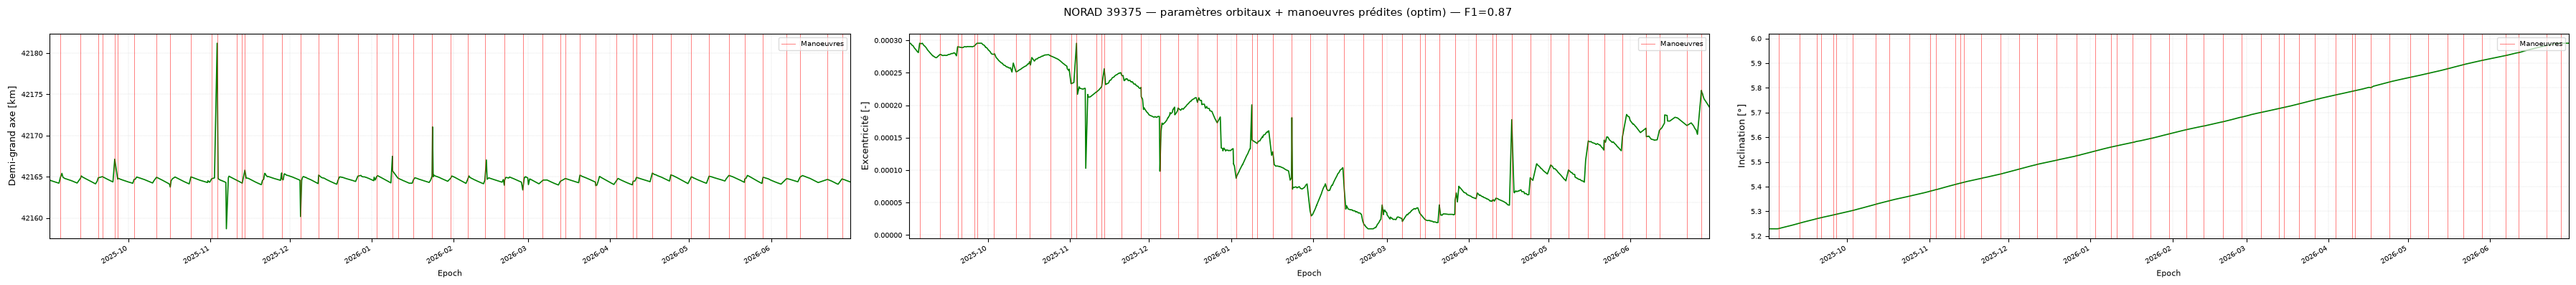

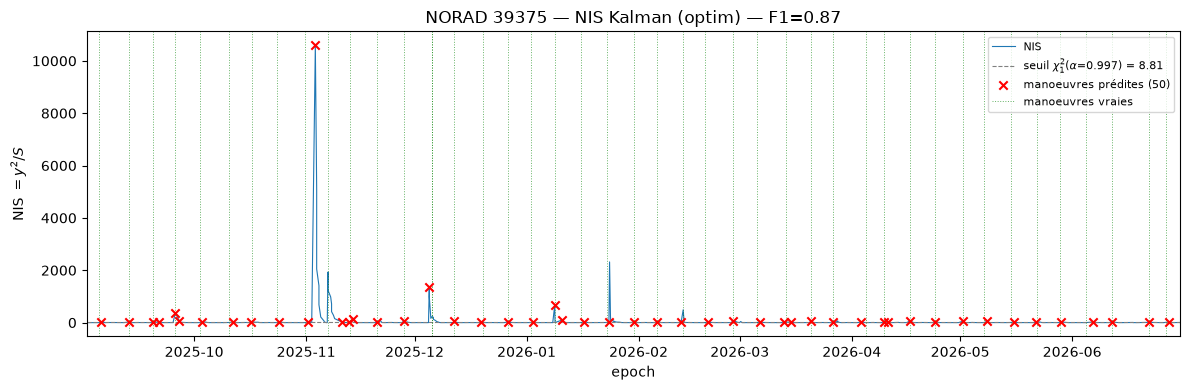

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


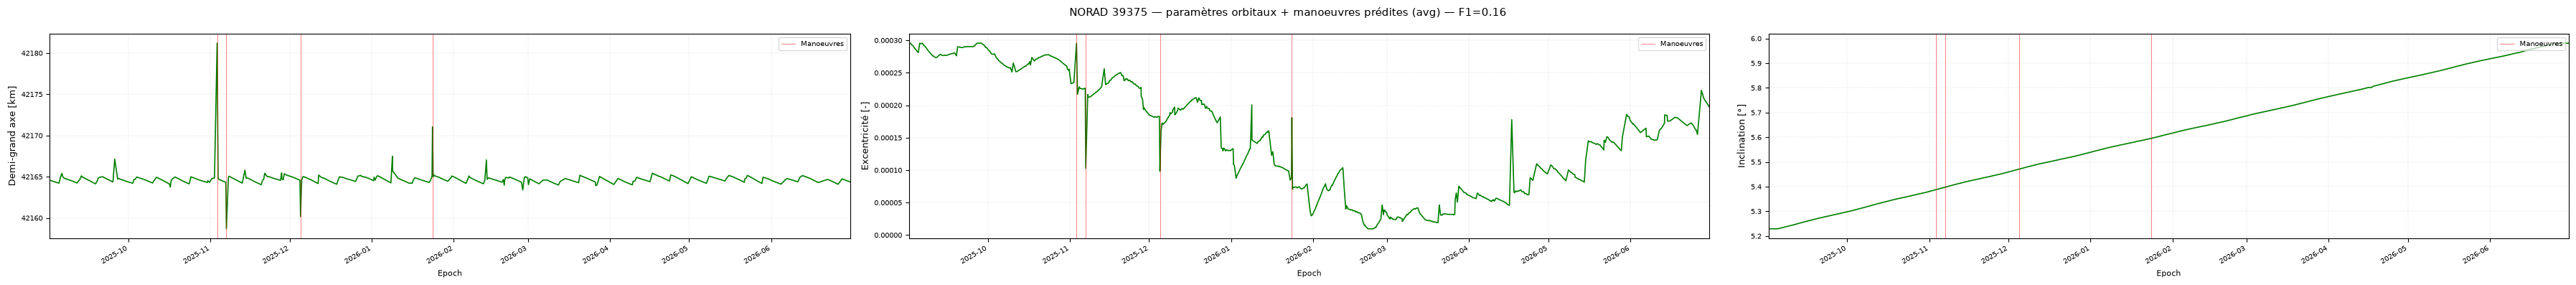

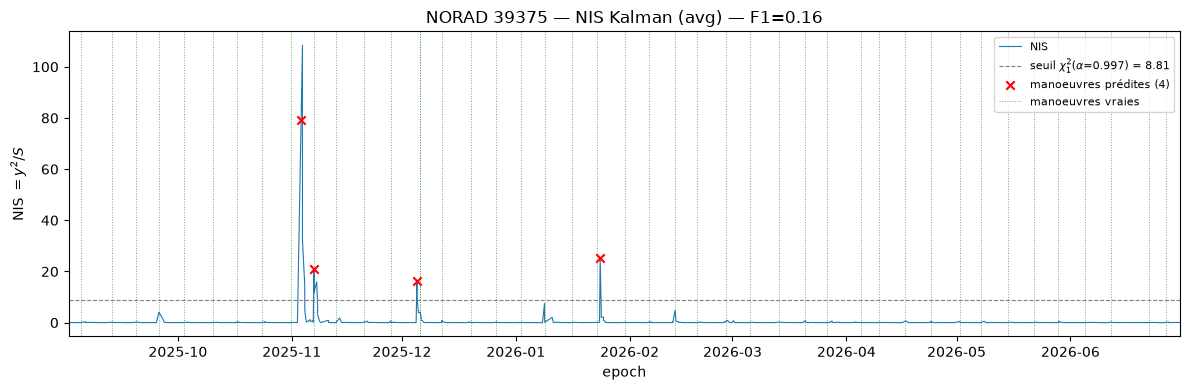

1


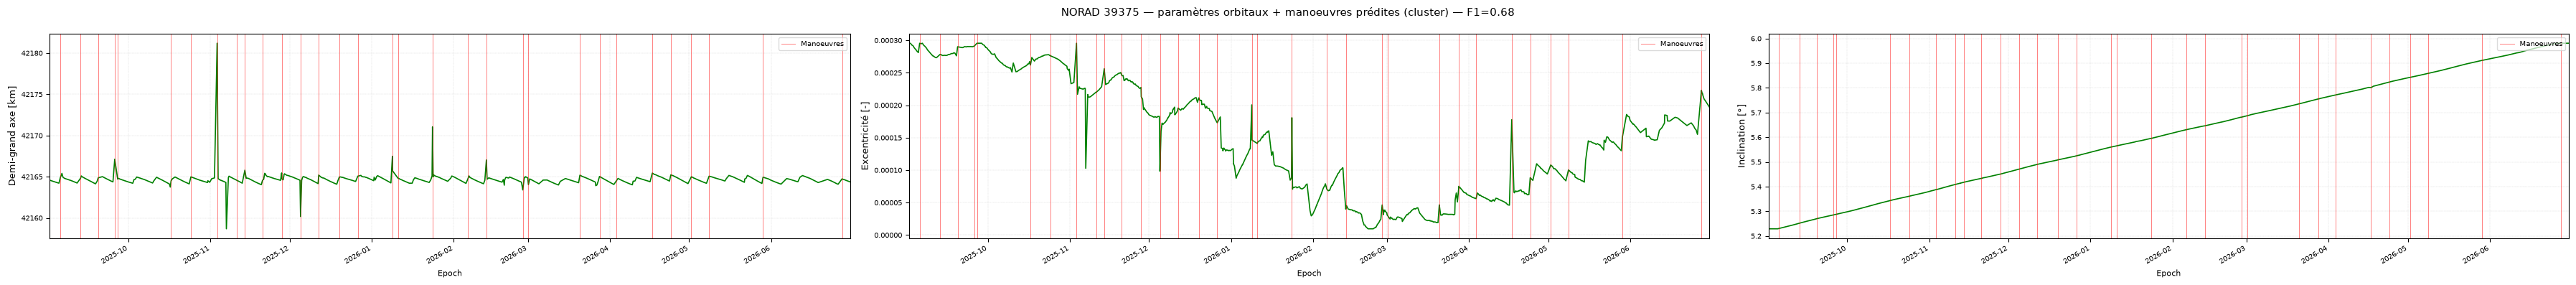

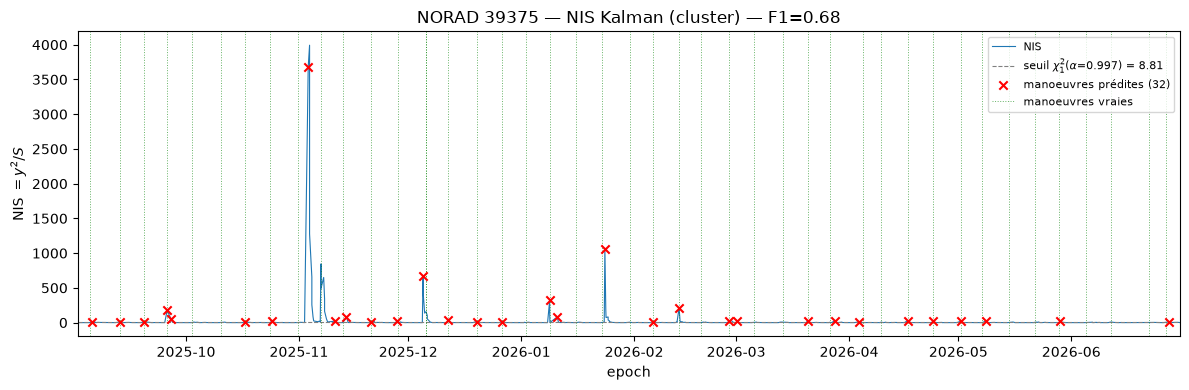

1


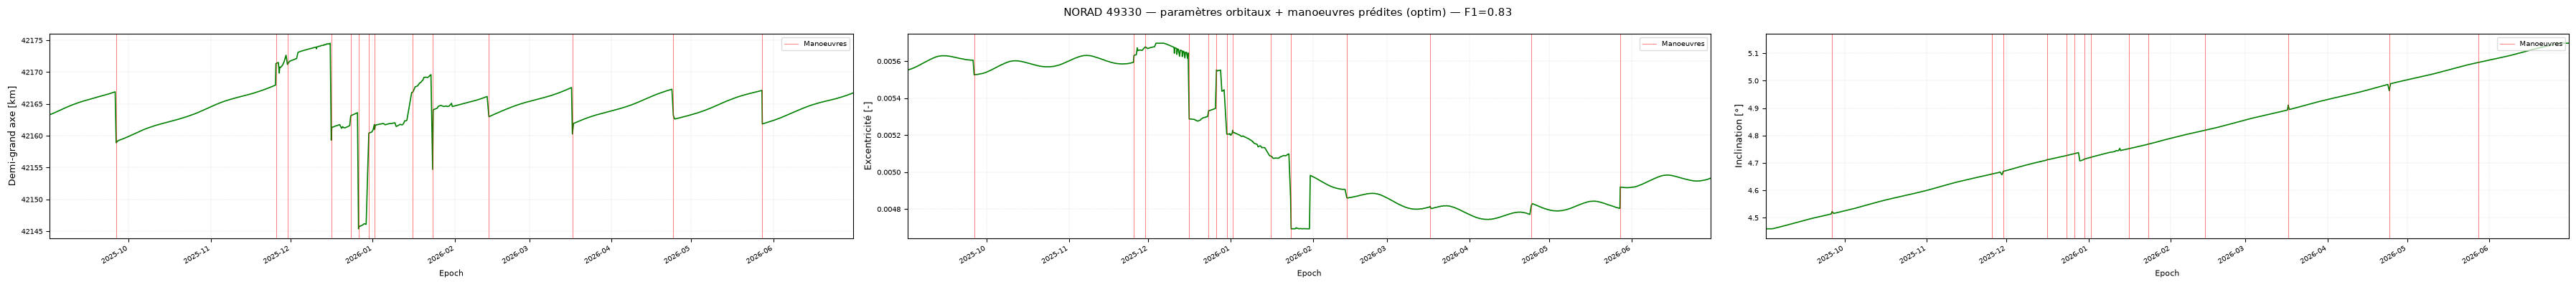

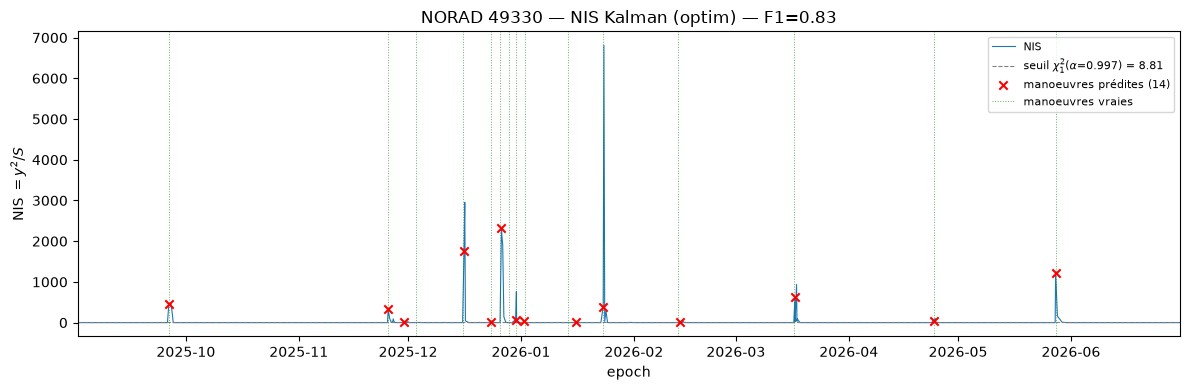

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


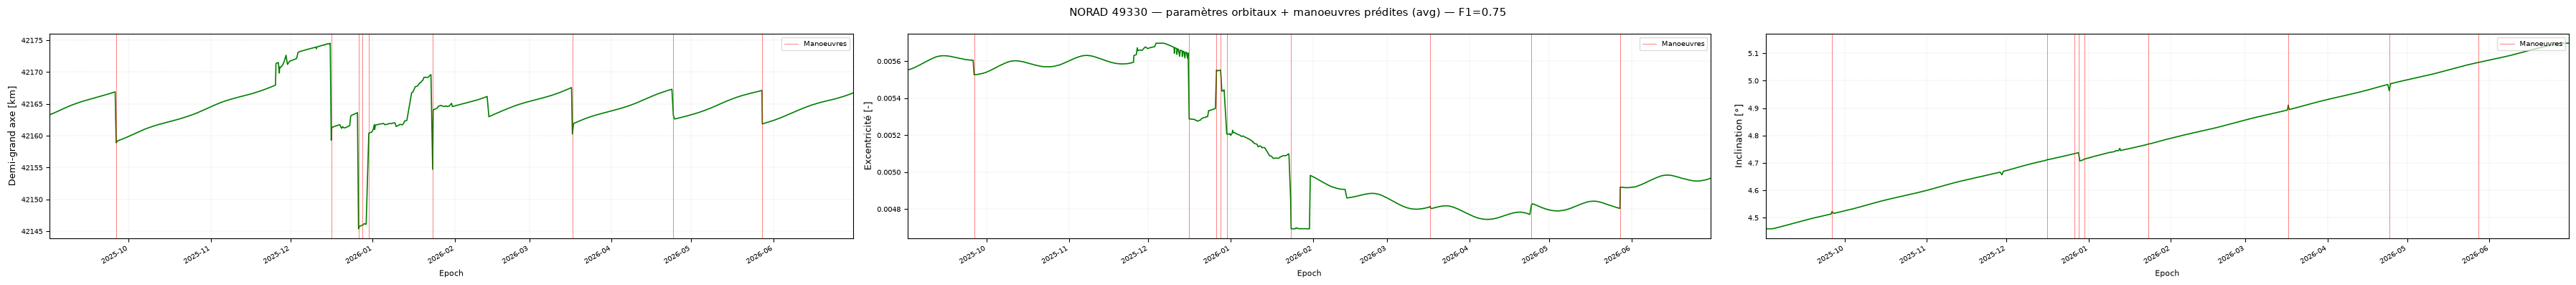

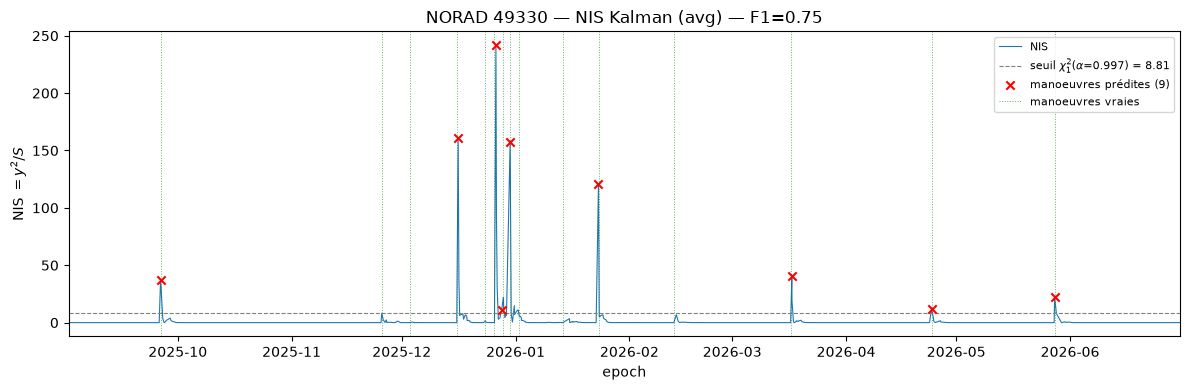

1


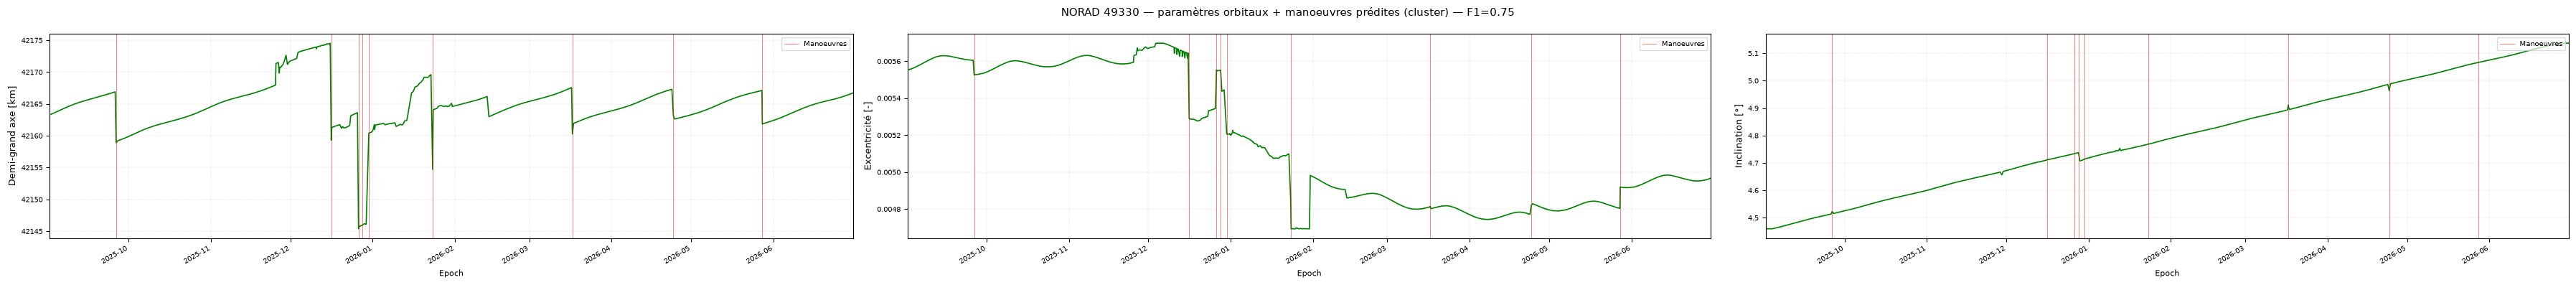

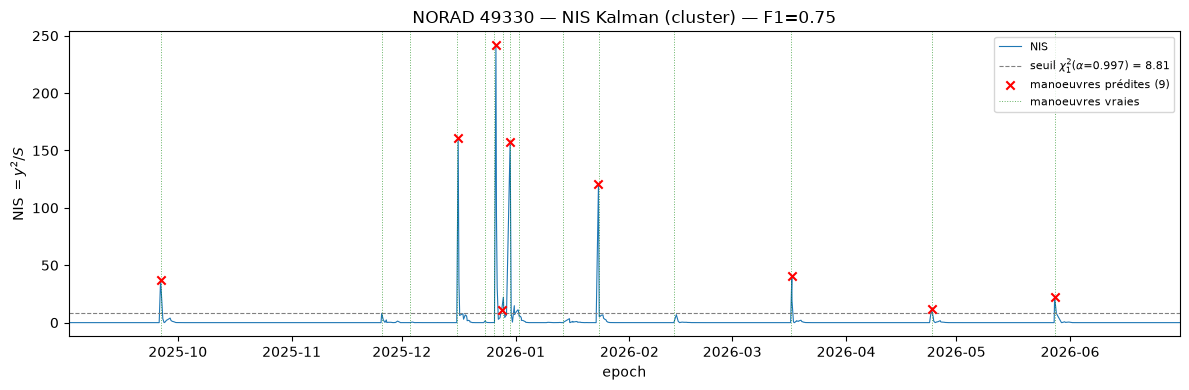

1


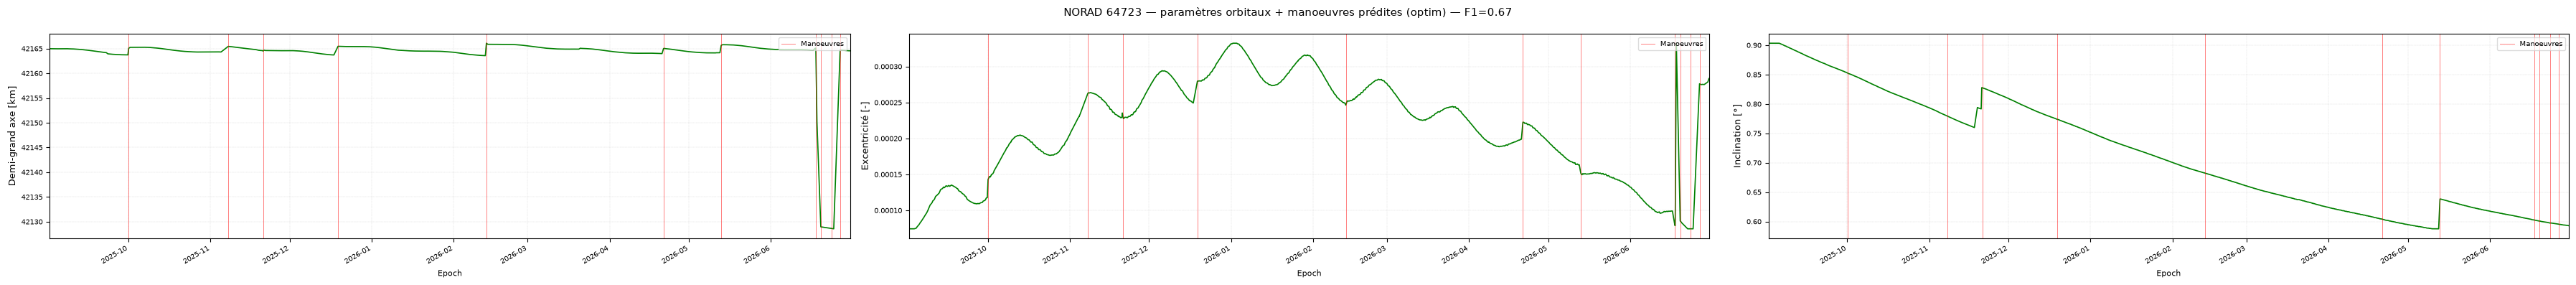

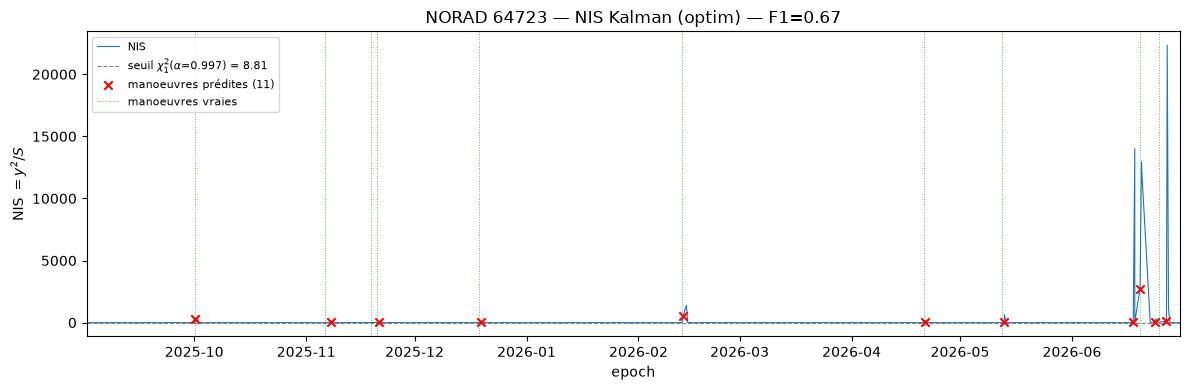

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


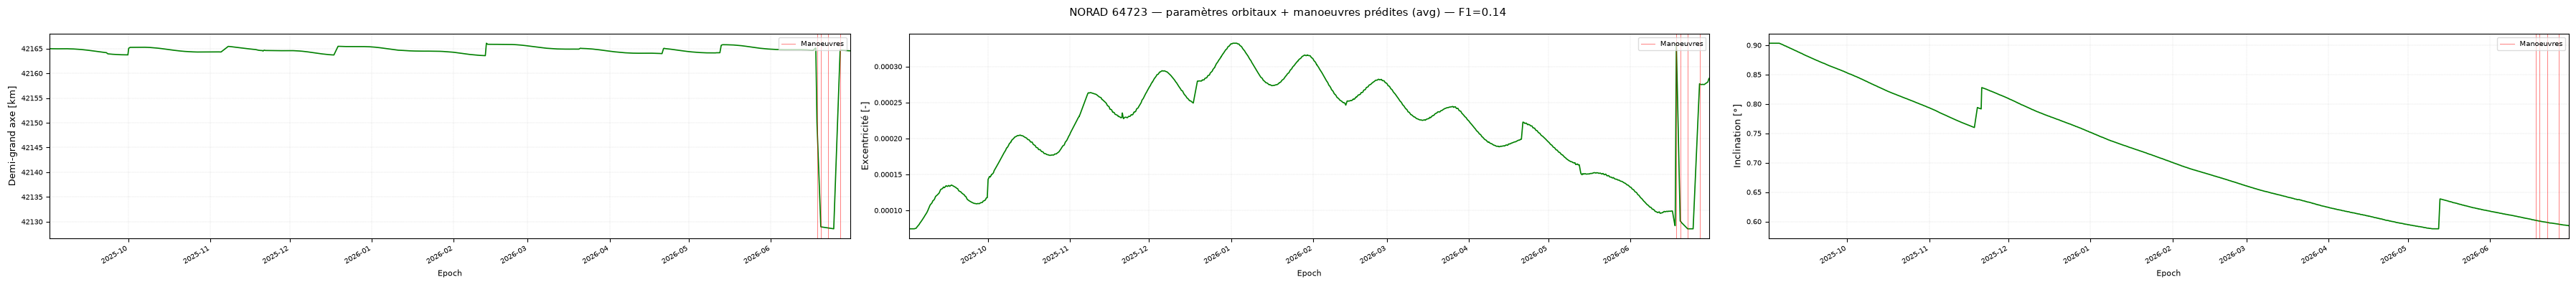

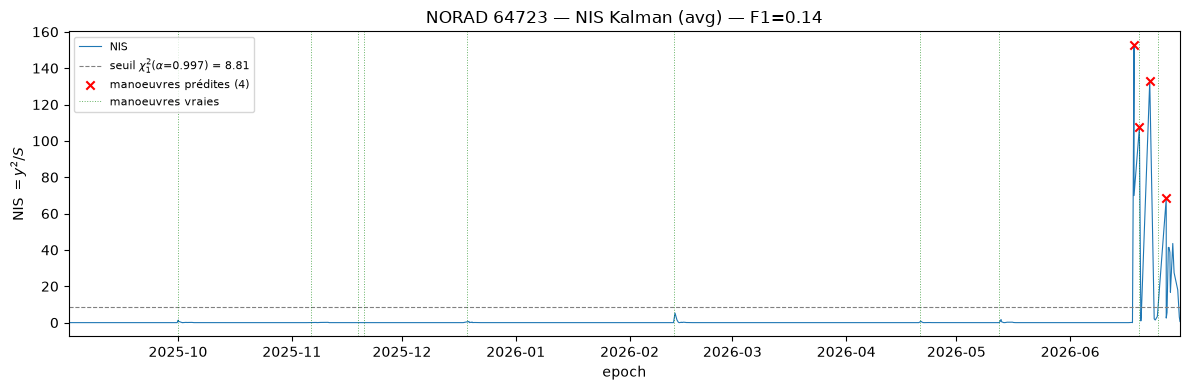

1


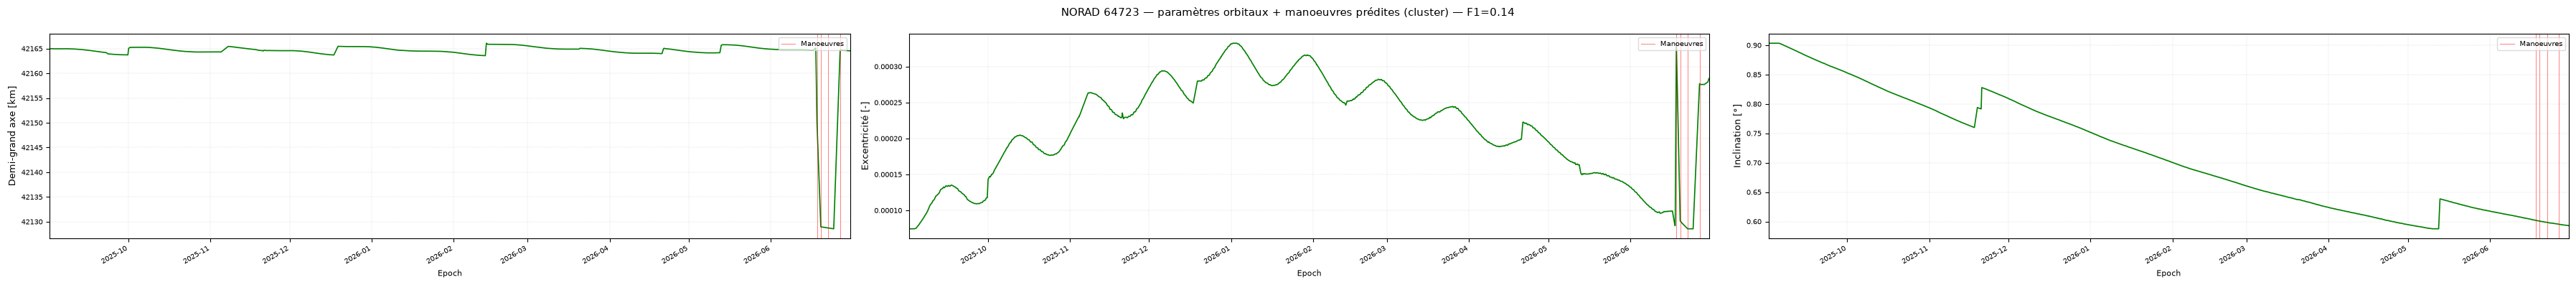

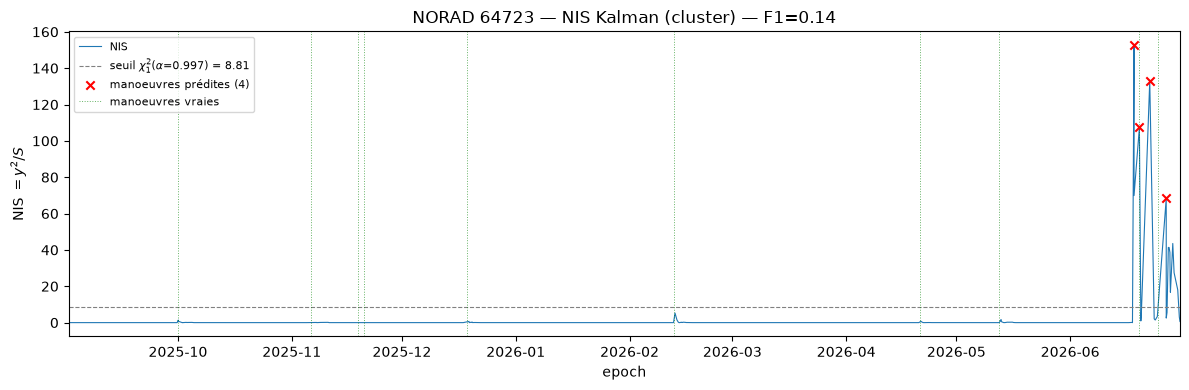

1


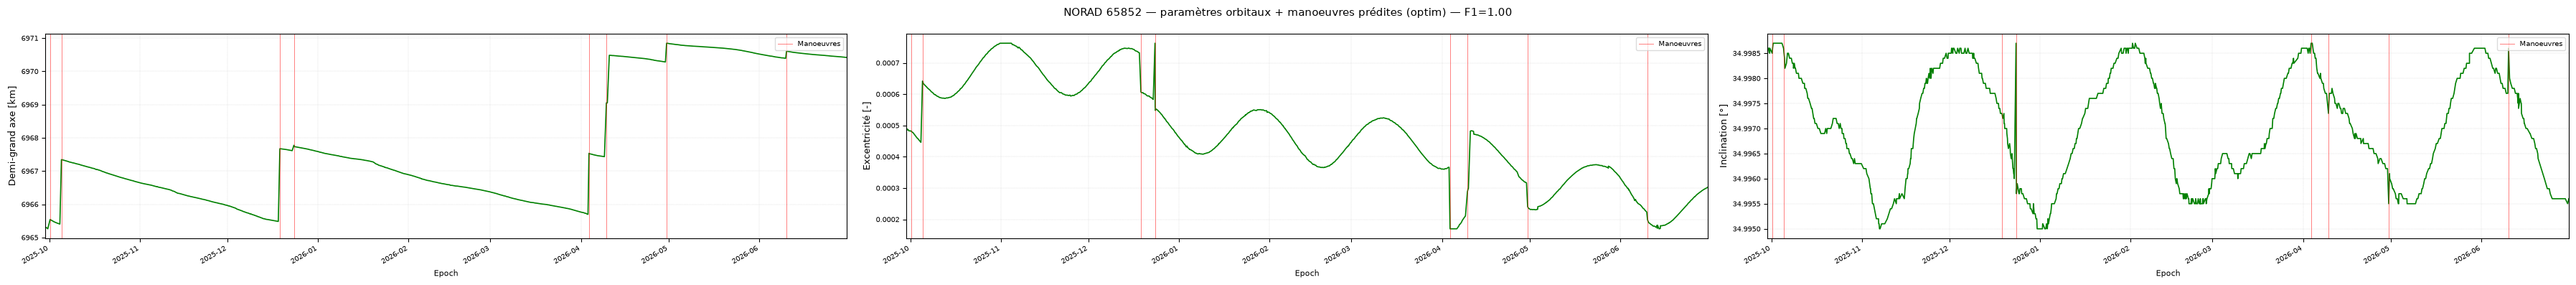

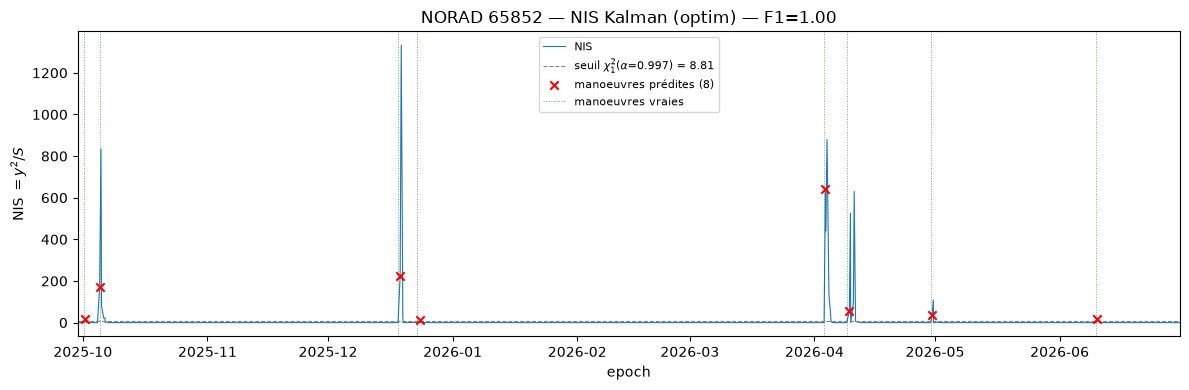

params moyens : var_Q=0.7139, r=0.9205, p0=8353, ordre=1
1


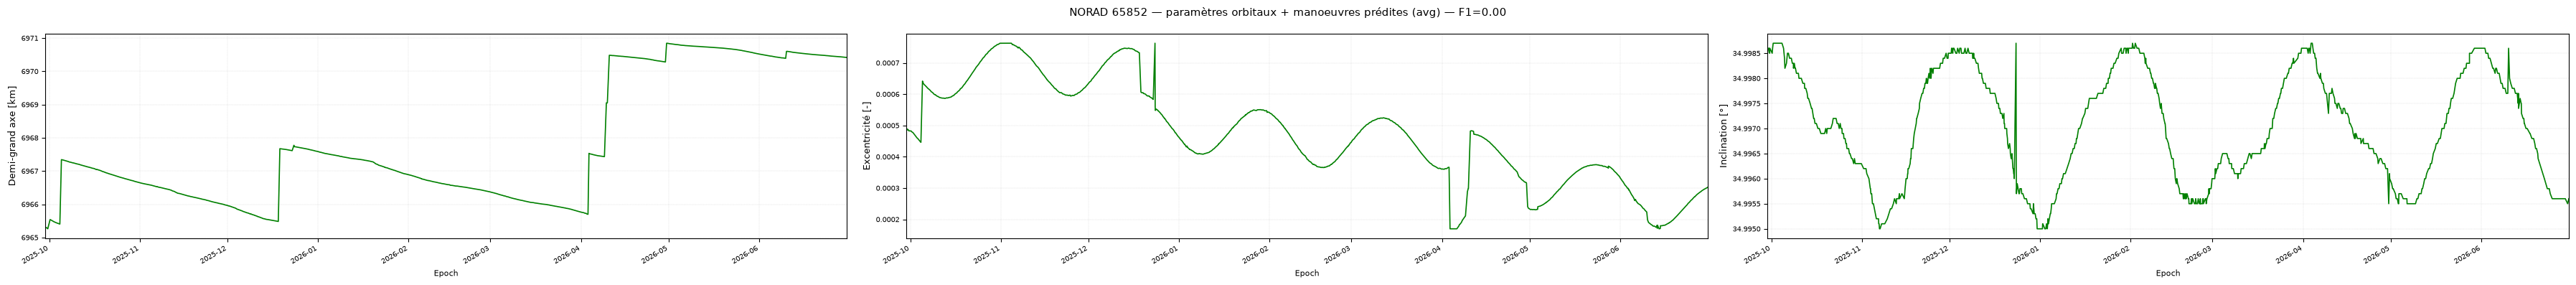

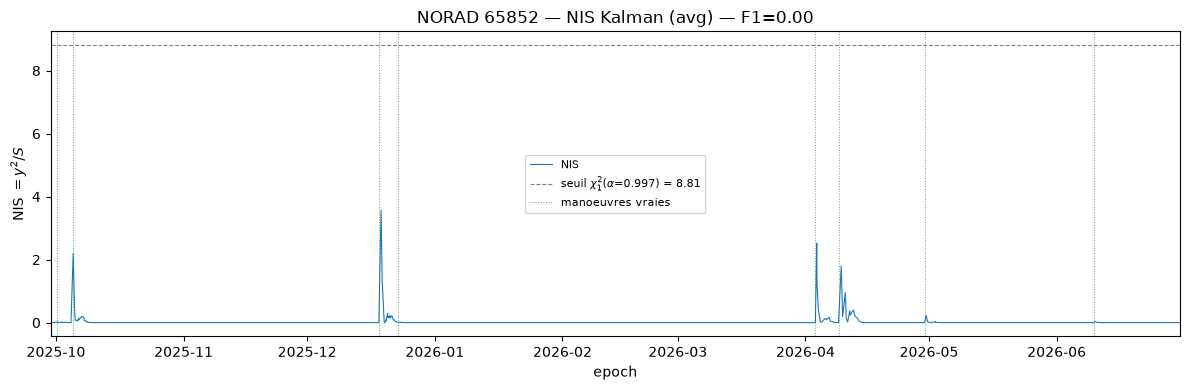

1


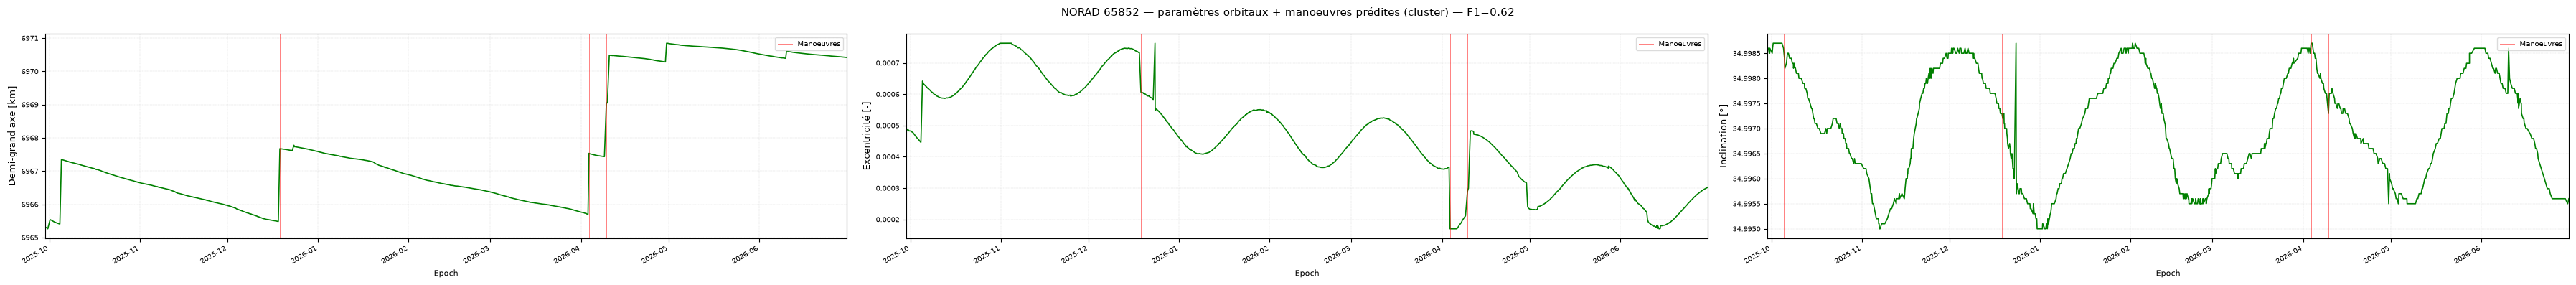

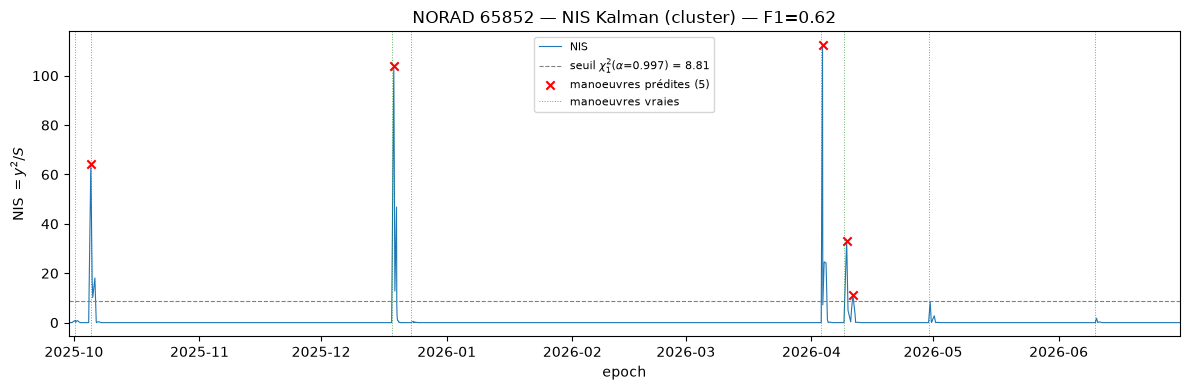

,cat,example,norad,config,precision,recall,f1,n_miss,n_false,n_det
0,fail,1,64467,optim,0.023810,0.500000,0.045455,1,41,1
1,fail,1,64467,avg,0.015625,0.500000,0.030303,1,63,1
2,fail,1,64467,cluster,0.015625,0.500000,0.030303,1,63,1
3,fail,2,64575,optim,0.200000,0.666667,0.307692,2,16,4
4,fail,2,64575,avg,0.000000,0.000000,0.000000,6,0,0
5,fail,2,64575,cluster,0.000000,0.000000,0.000000,6,0,0
6,mid,1,28885,optim,0.653846,0.850000,0.739130,3,9,17
7,mid,1,28885,avg,0.400000,0.100000,0.160000,18,3,2
8,mid,1,28885,cluster,0.400000,0.100000,0.160000,18,3,2
9,mid,2,62904,optim,0.196078,0.588235,0.294118,7,41,10


In [25]:
## Exemples représentatifs par catégorie : F1 réparties sur la plage de la
## catégorie, davantage d'exemples pour good / perfect. Noms de figures
## déterministes pour le rapport :
##   kalman_{cat}{k}_{config}_params.png / kalman_{cat}{k}_{config}_nis.png

N_EXAMPLES = {"fail": 2, "mid": 2, "good": 5, "perfect": 3}

df_all = pd.read_csv(clusters_csv)

examples = {"fail" : [64467, 64575], "mid" : [28885, 62904], "good" : [64784, 65317, 63920, 39375, 49330], "perfect" : [64723, 65852,]}    ## {cat: [norads]}

print("exemples choisis :", examples)

runners = {
    "optim":   run_filters_with_optim_params,
    "avg":     run_filters_with_avg_params,
    "cluster": run_filters_with_cluster_params,
}

summary = []
for cat, norads_ex in examples.items():
    for k, norad in enumerate(norads_ex, start=1):
        for config, runner in runners.items():
            res = runner([norad], clusters_csv, tag=config,
                         names={norad: f"kalman_{cat}{k}_{config}"})
            m = res.get(norad)
            if m:
                summary.append({"cat": cat, "example": k, "norad": norad,
                                "config": config, **m})

summary_df = pd.DataFrame(summary)
summary_df.to_csv(figures_dir / "kalman_examples_f1_summary.csv", index=False)
summary_df

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


/home/echevrolat/Documents/dev/ssa-analysis/src/maneuver_detection/discrete_kalman_filter.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f.x = np.array([a[0],(a[1] - a[0])/dt[0]])


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
            f1  precision  recall
config                           
avg      0.105      0.162   0.118
cluster  0.288      0.309   0.328
optim    0.605      0.563   0.720


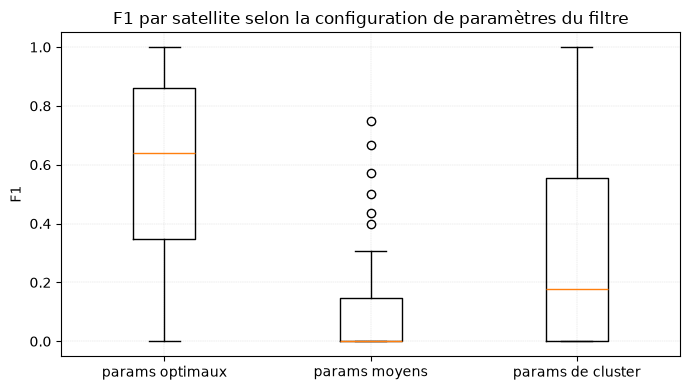

In [26]:
## Comparaison F1 optim / avg / cluster sur TOUS les satellites labellisés
## (métriques seules, pas de figures individuelles) + boxplot pour le rapport

def compare_configs_f1(csv_path):
    df = pd.read_csv(csv_path)
    global_means, cluster_means, global_order, cluster_orders = _cluster_param_tables(df)
    rows = []
    for _, row in df.iterrows():
        norad = int(row['norad'])
        c = int(row['cluster'])
        if c == -1:
            cl_params, cl_order = global_means, global_order
        else:
            cl_params, cl_order = tuple(cluster_means.loc[c].tolist()), int(cluster_orders.loc[c])
        configs = {
            "optim":   (int(row['order']), row['var_Q'], row['r'], row['p0']),
            "avg":     (global_order, *global_means),
            "cluster": (cl_order, *cl_params),
        }
        for config, (order, var_Q, r, p0) in configs.items():
            m = f1_for_params(norad, order, var_Q, r, p0)
            if m:
                rows.append({"norad": norad, "config": config, "f1": m['f1'],
                             "precision": m['precision'], "recall": m['recall']})
    return pd.DataFrame(rows)

comparison_df = compare_configs_f1(clusters_csv)
comparison_df.to_csv(figures_dir / "kalman_f1_comparison_configs.csv", index=False)

## moyennes par config
print(comparison_df.groupby("config")[["f1", "precision", "recall"]].mean().round(3))

## boxplot F1 par config
fig, ax = plt.subplots(figsize=(7, 4))
order_cfg = ["optim", "avg", "cluster"]
data = [comparison_df[comparison_df.config == c].f1 for c in order_cfg]
ax.boxplot(data, tick_labels=["params optimaux", "params moyens", "params de cluster"])
ax.set_ylabel("F1")
ax.set_title("F1 par satellite selon la configuration de paramètres du filtre")
ax.grid(True, ls="--", lw=0.3, alpha=0.5)
fig.tight_layout()
fig.savefig(figures_dir / "kalman_f1_comparison_configs.png", dpi=150, bbox_inches="tight")
plt.show()